Cerco file .npz in: /Users/benussi/Testbeam2026_WC_single/data
Trovati 178 file totali.
Peak finder: numpy-only (height=5.0 mV, distance=1 samples = 0.5 ns, prominence=2.0 mV, search_from_rising_edge=True)
Integrale Q: gate [-10.0, +150.0] ns dal rising edge della SUM, unità = ADC counts integrati


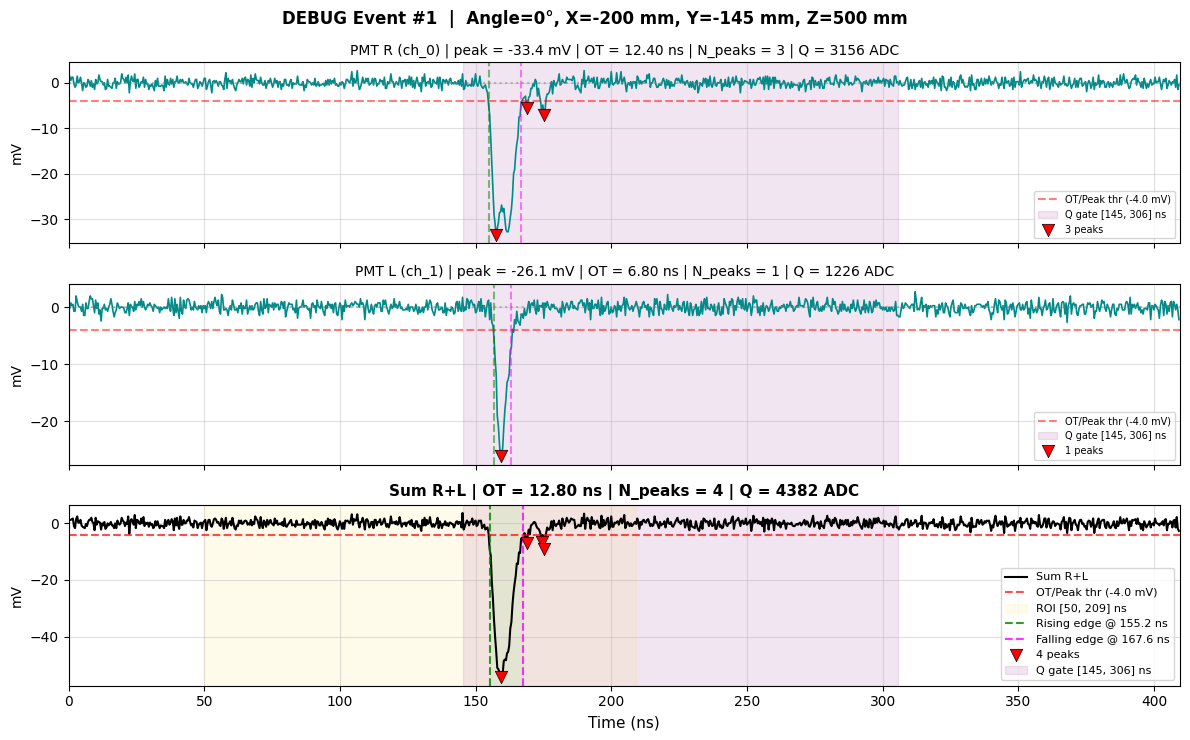

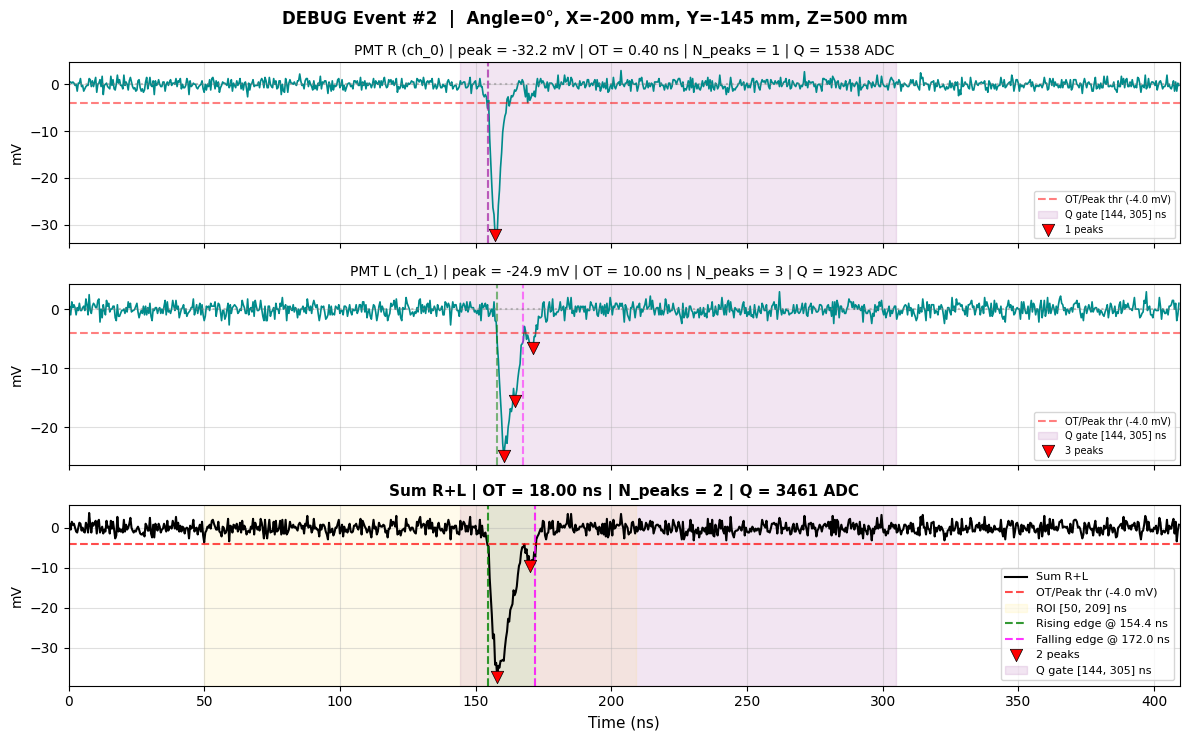

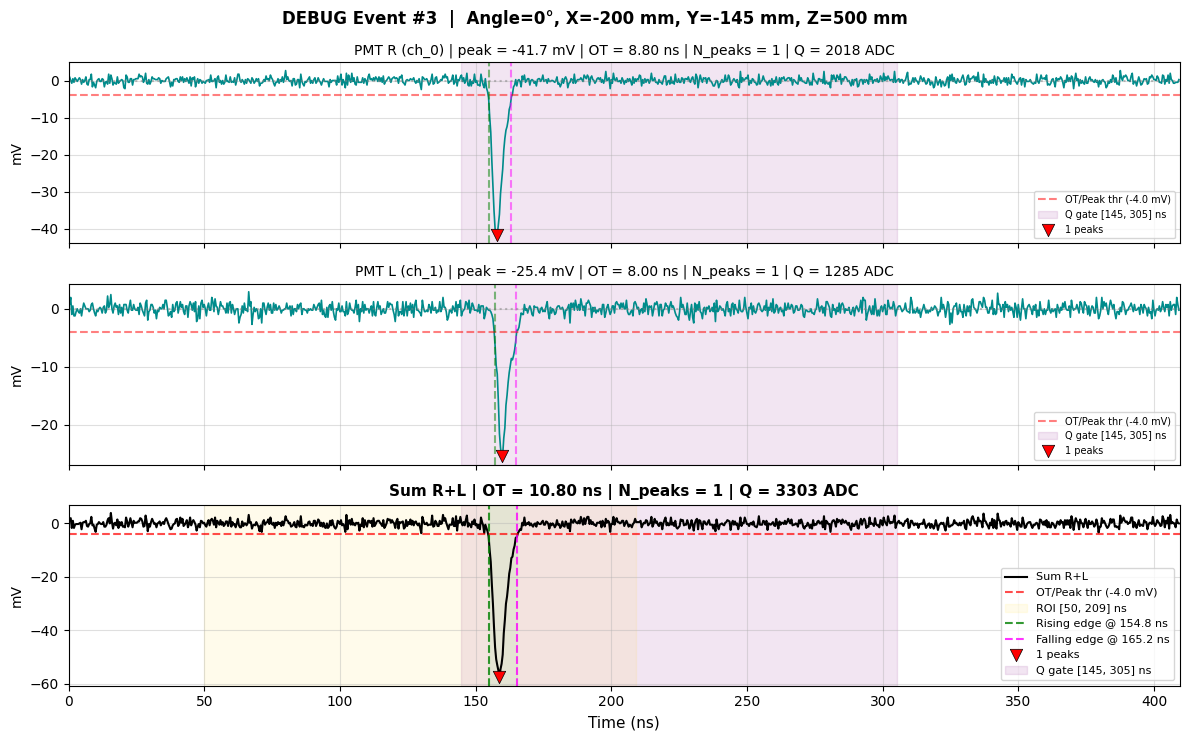


File processati: 175
Eventi totali  : 175000
Angoli trovati : [0.0, 10.0, 20.0, 30.0, 40.0, 50.0, 60.0]
X trovate (mm) : [-400.0, -200.0, 0.0, 200.0, 400.0]
Y trovate (mm) : [-145.0, -75.0, 0.0, 75.0, 145.0]

##################################################################################
#  AGGREGAZIONE PER Y (marginalizzata su X)
##################################################################################

  CANALE: R  (PMT_ID = [0])  —  Osservabile: OT  —  Separato per Y
    Y (mm)    Angle    N_evt           <OT>      sigma        SEM
----------------------------------------------------------------------------------
    -145.0      0.0     4998          9.192      3.501      0.050
    -145.0     10.0     4999          9.168      3.432      0.049
    -145.0     20.0     4998          9.518      3.428      0.048
    -145.0     30.0     4997          9.936      3.472      0.049
    -145.0     40.0     5000         10.672      3.394      0.048
    -145.0     50.0     5000     

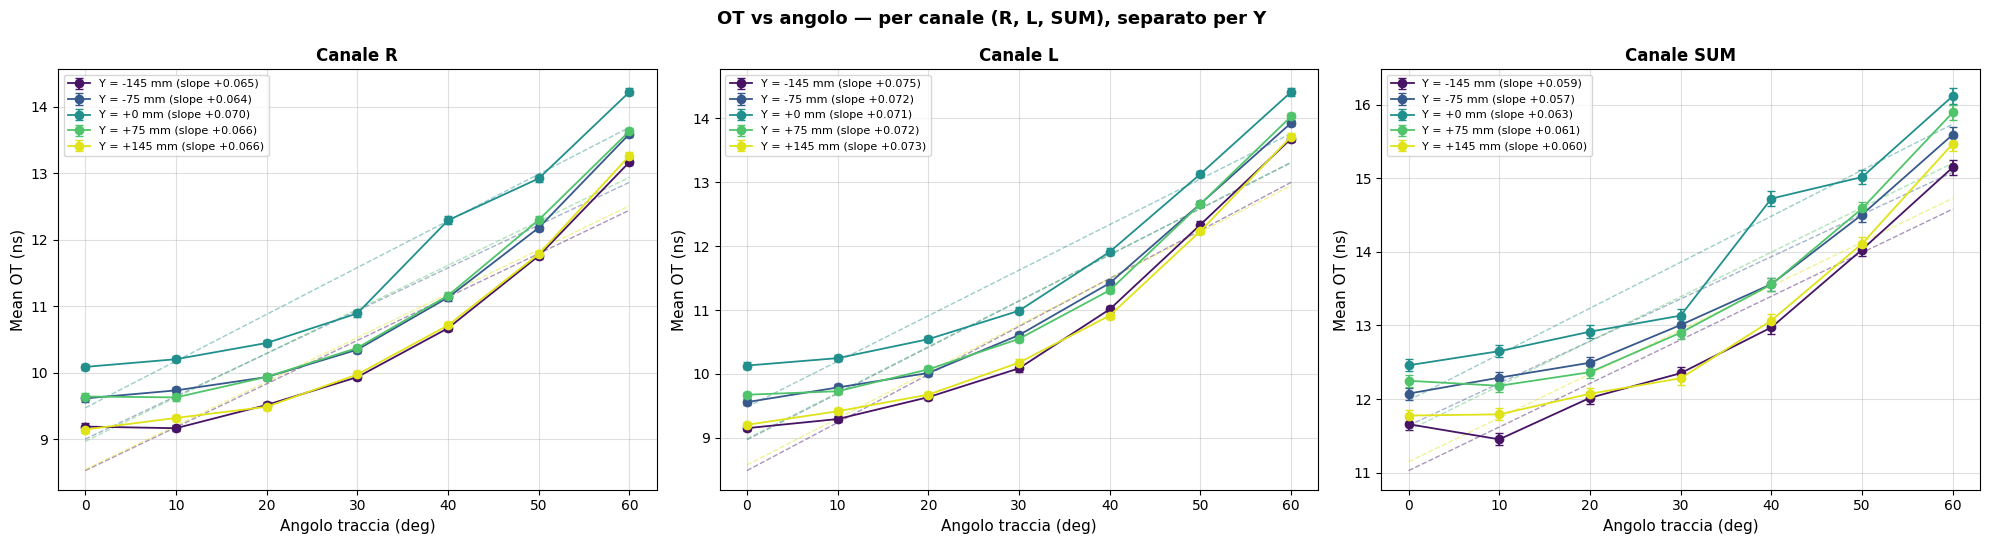

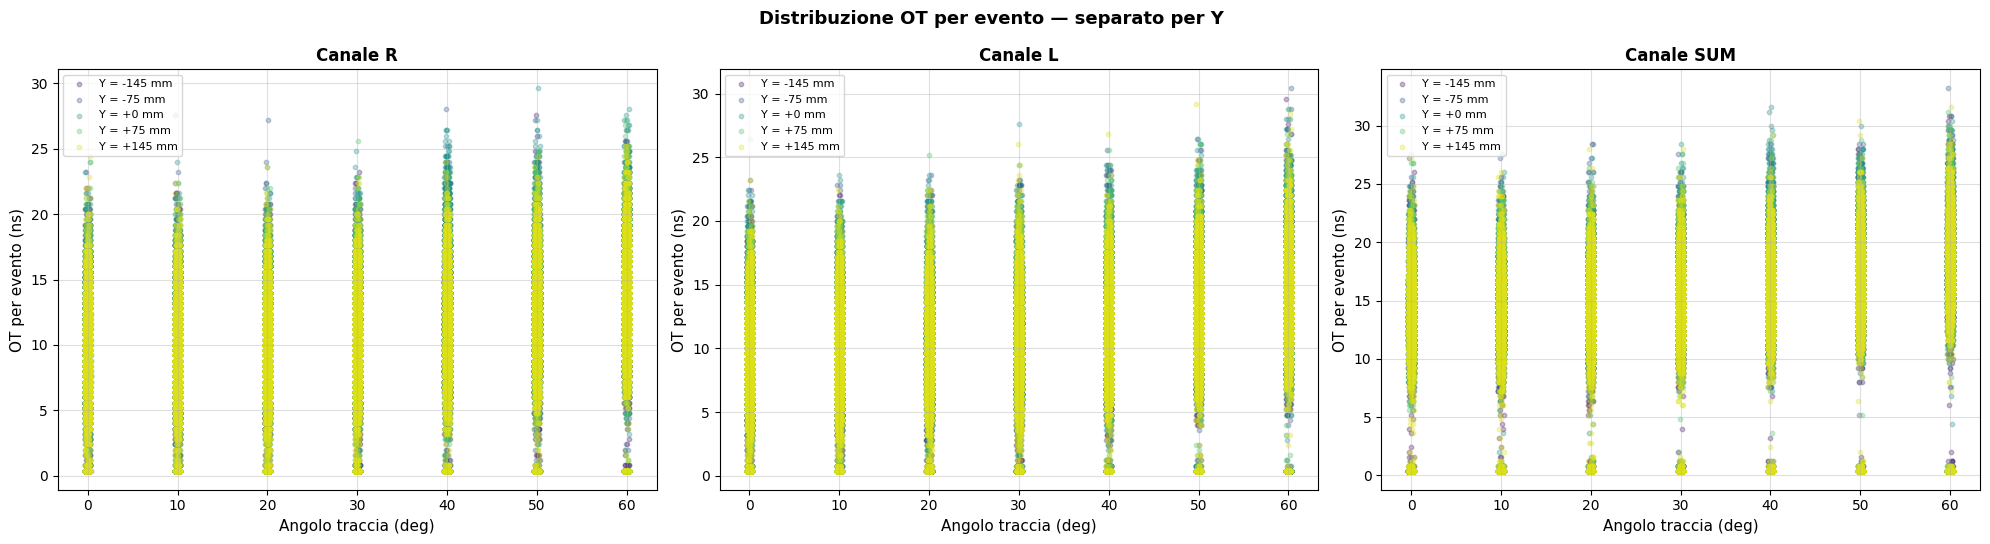

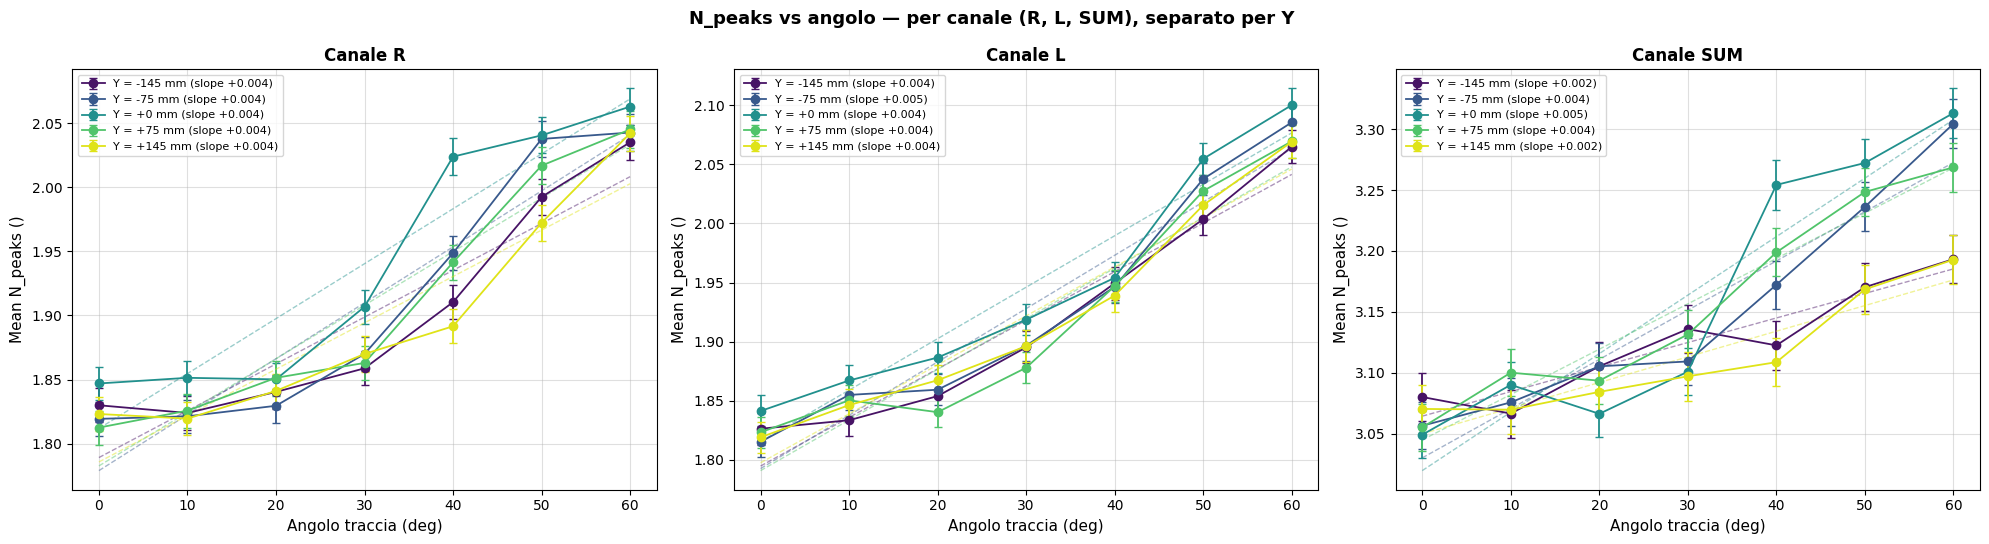

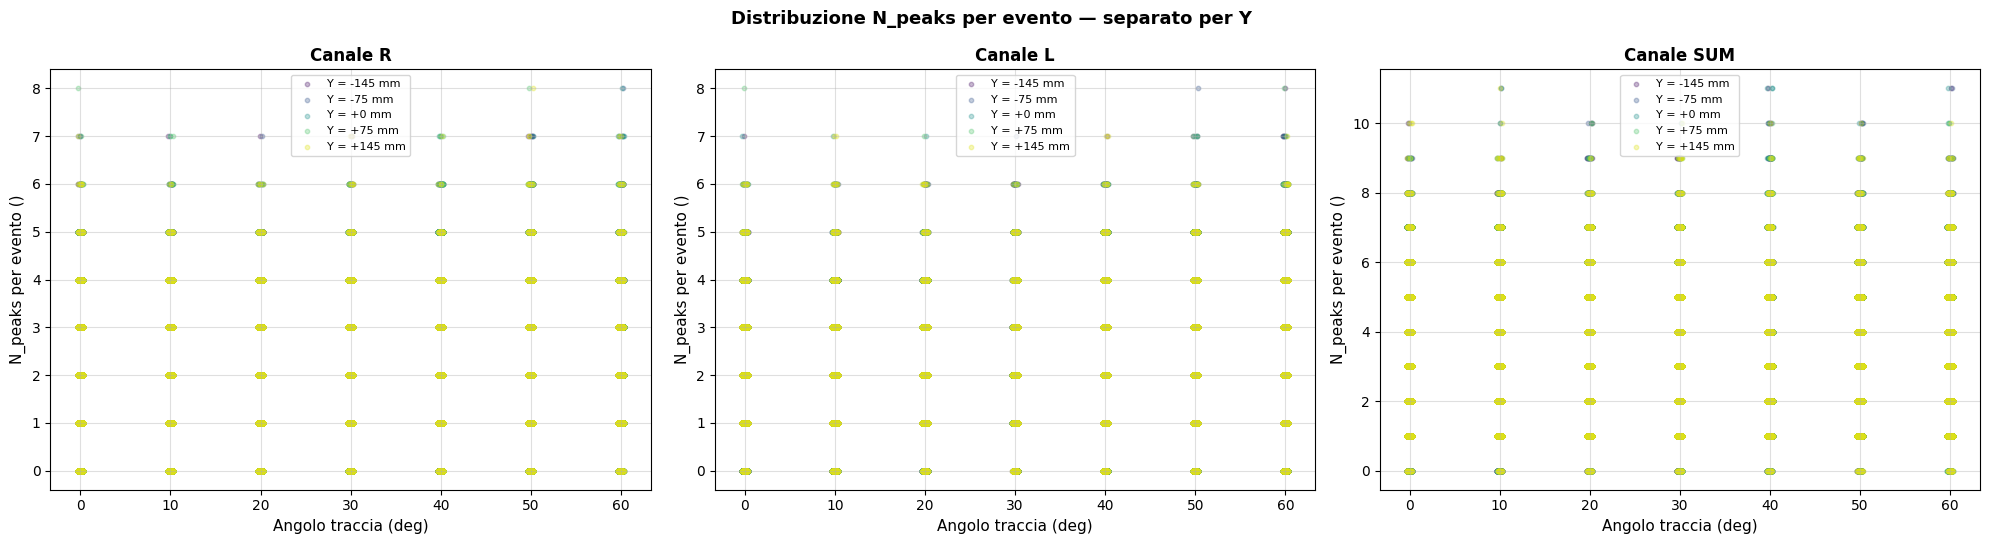

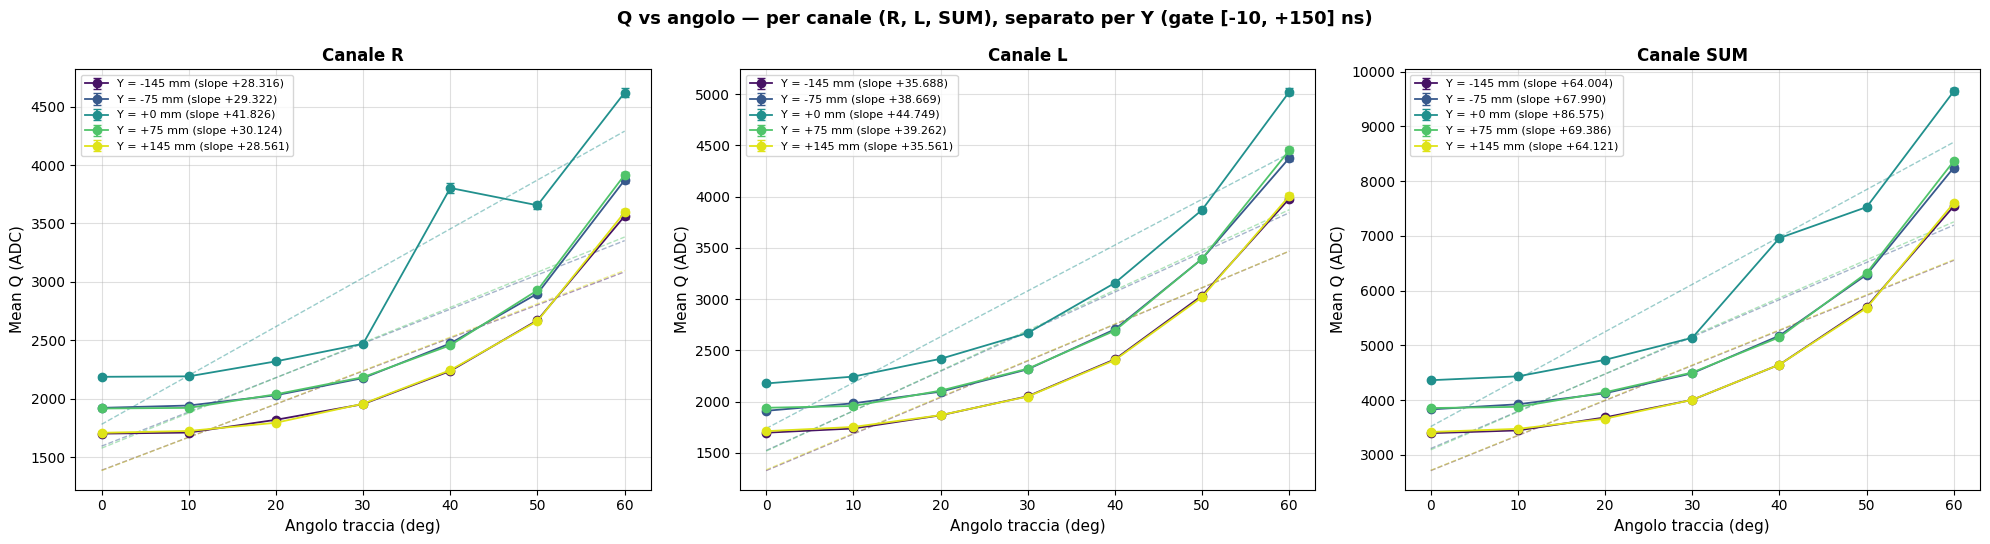

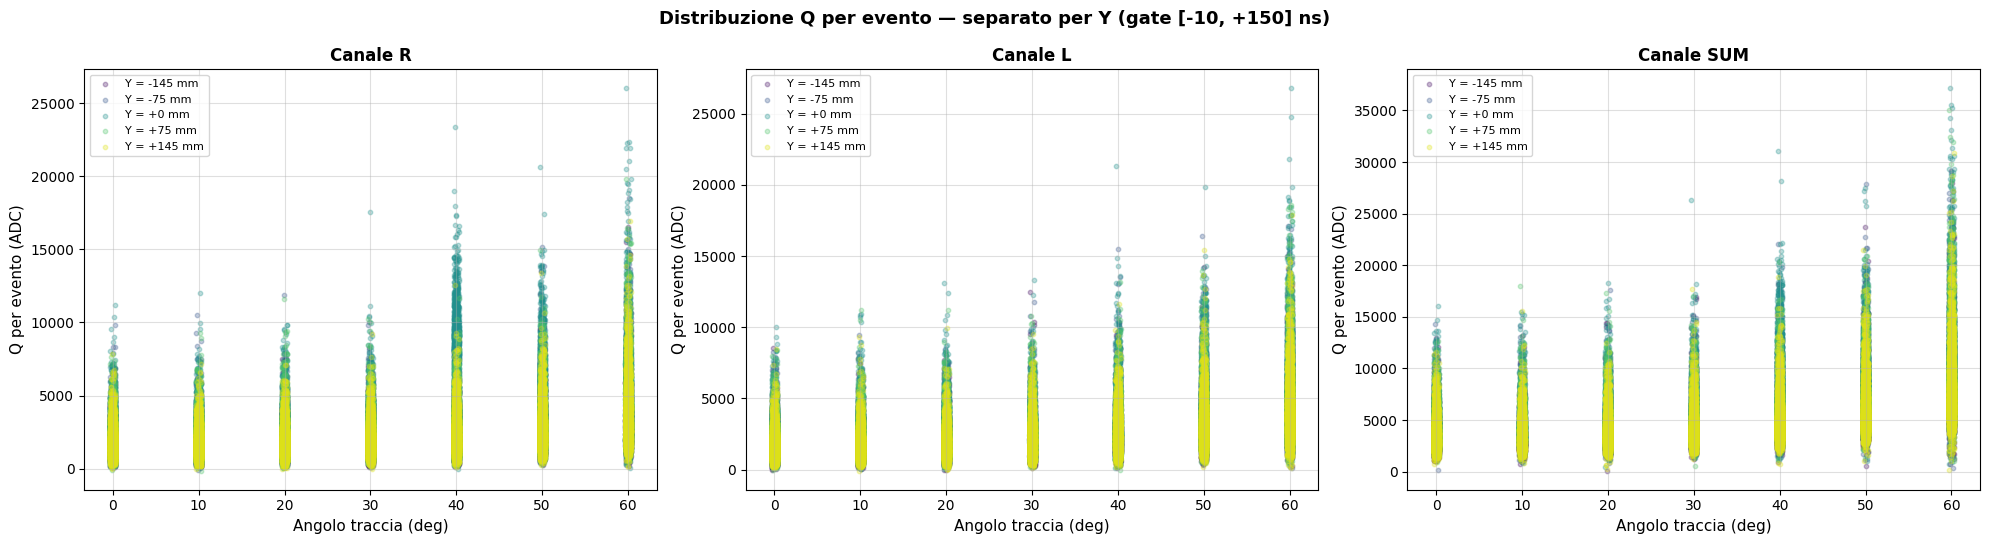

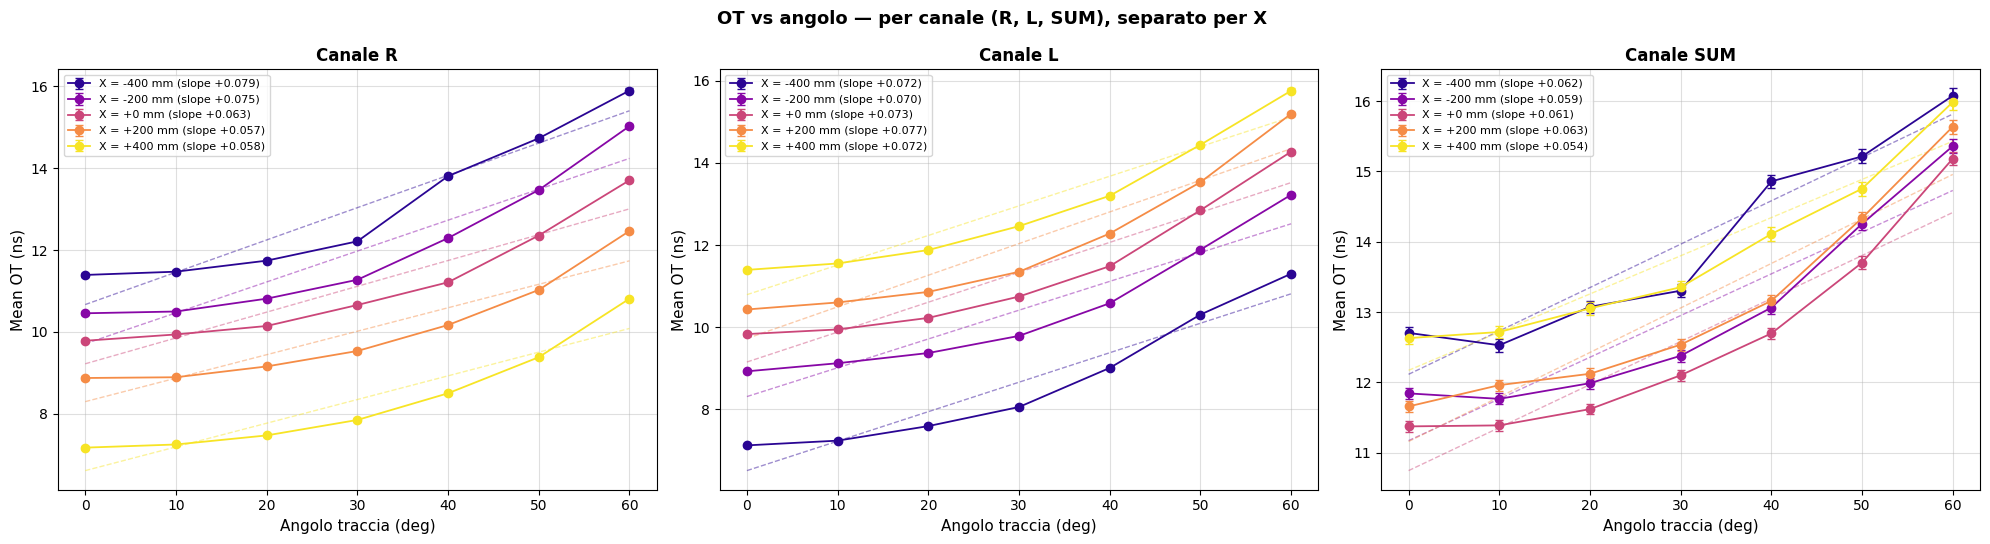

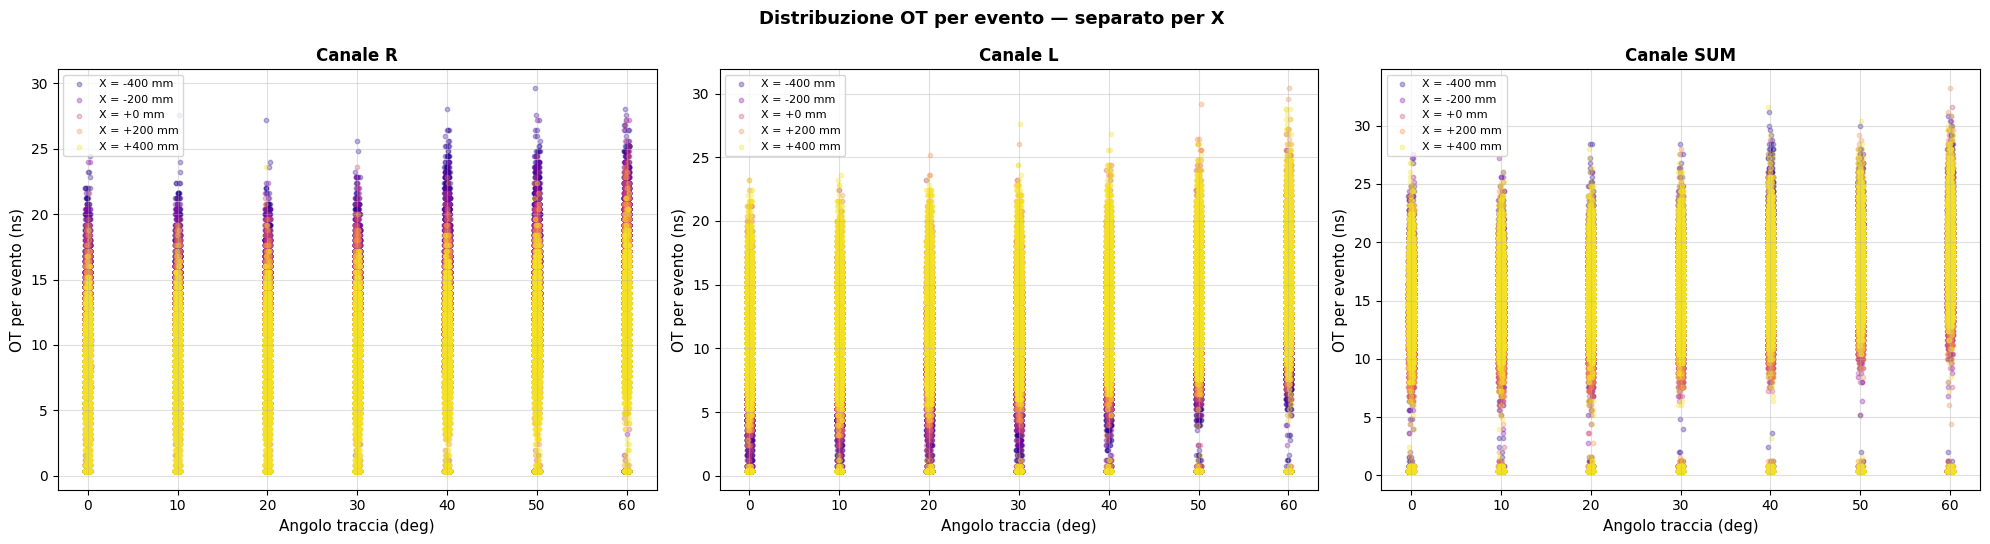

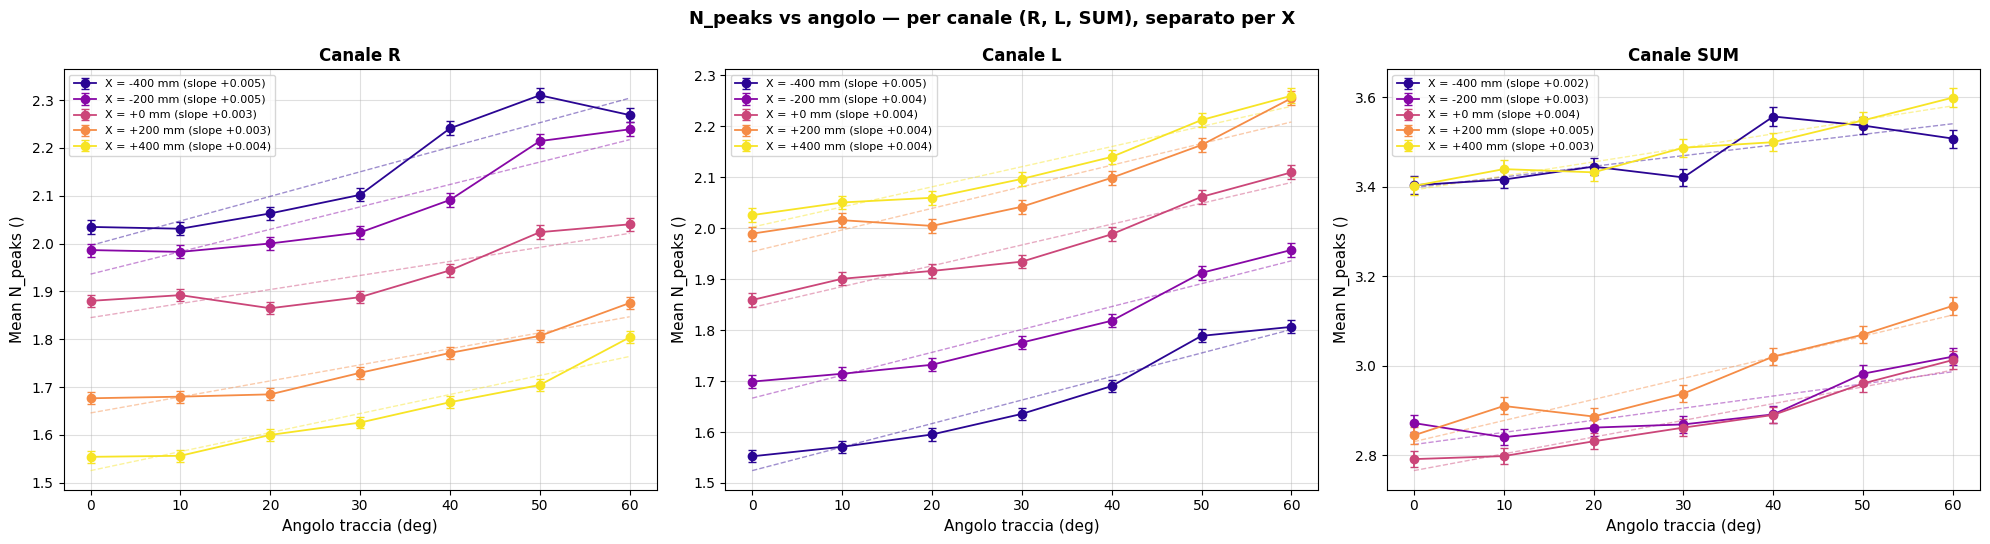

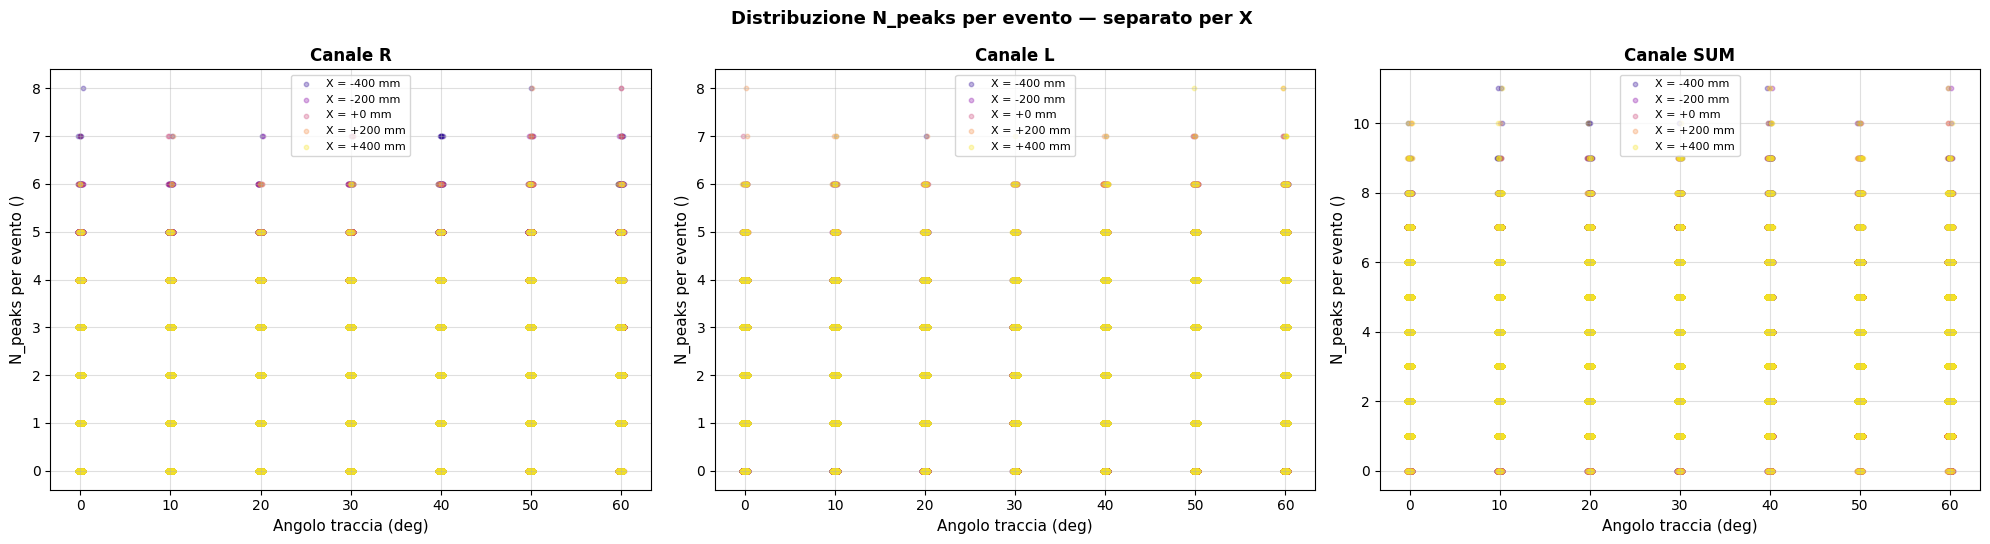

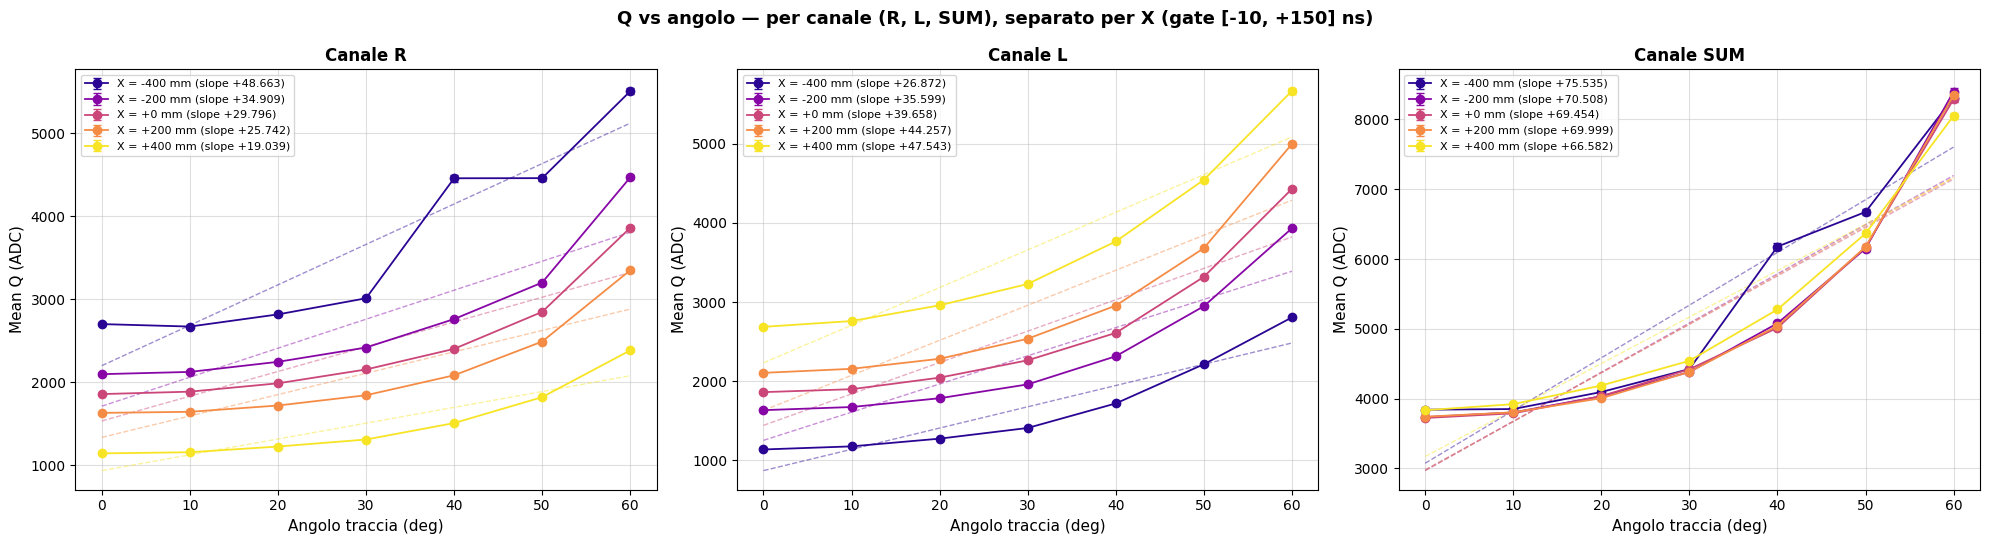

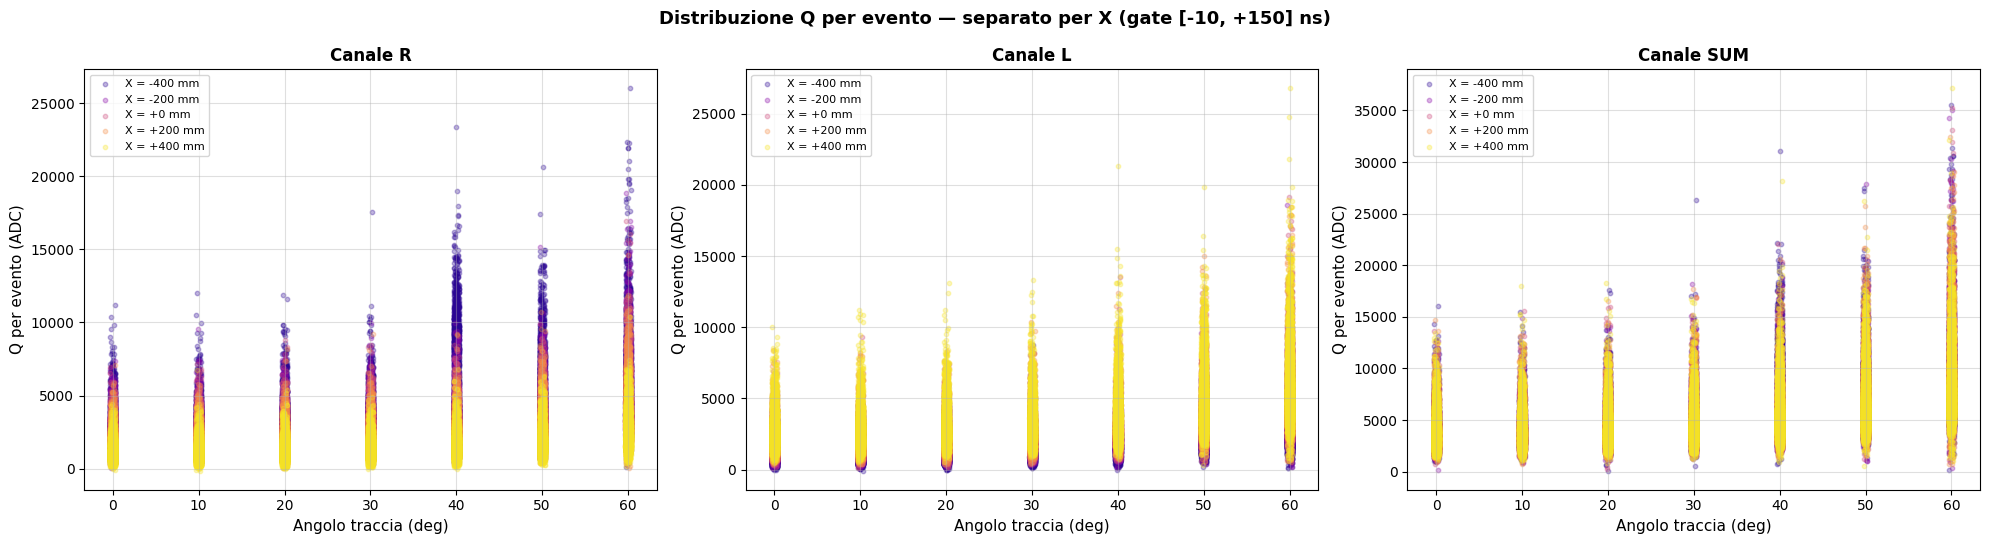


  log(Q_R/Q_L) vs angolo — separato per X (marginalizzato su Y)
    X (mm)    Angle    N_evt        <logQr>      sigma        SEM
----------------------------------------------------------------------------------
    -400.0      0.0     4998        +0.9042     0.4804     0.0068
    -400.0     10.0     4999        +0.8563     0.4674     0.0066
    -400.0     20.0     4997        +0.8244     0.4489     0.0064
    -400.0     30.0     5000        +0.7878     0.4231     0.0060
    -400.0     40.0     4999        +0.8800     0.5129     0.0073
    -400.0     50.0     5000        +0.6874     0.3768     0.0053
    -400.0     60.0     5000        +0.6801     0.3321     0.0047
    -200.0      0.0     5000        +0.2612     0.4306     0.0061
    -200.0     10.0     5000        +0.2481     0.4120     0.0058
    -200.0     20.0     5000        +0.2413     0.4107     0.0058
    -200.0     30.0     5000        +0.2178     0.3878     0.0055
    -200.0     40.0     5000        +0.1835     0.3581     0

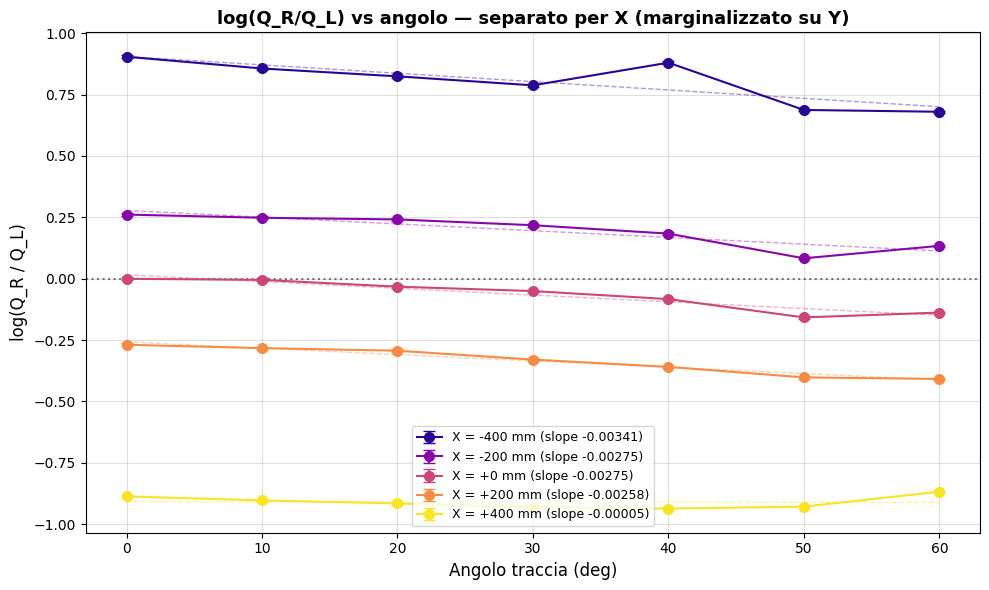

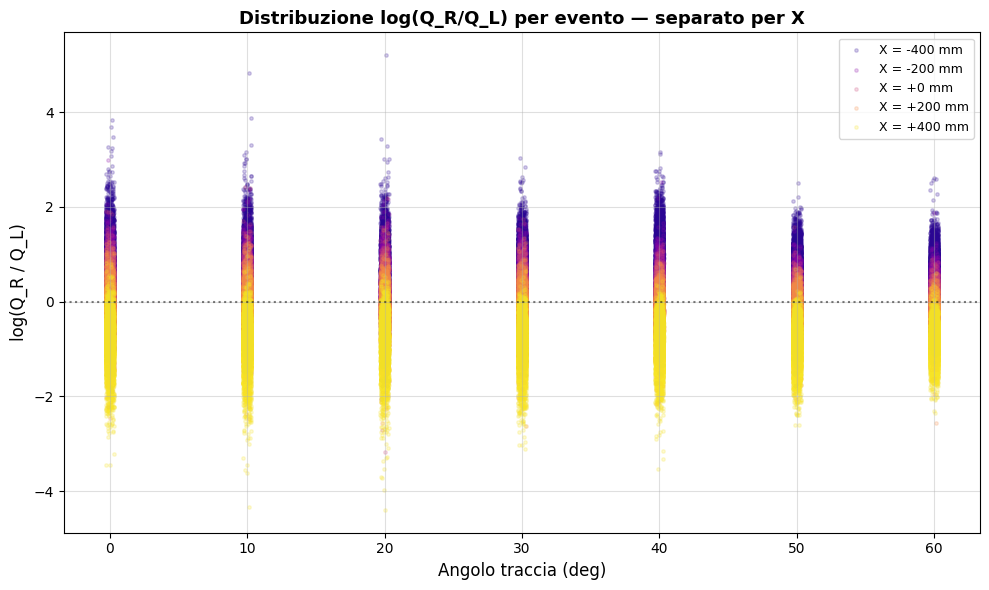

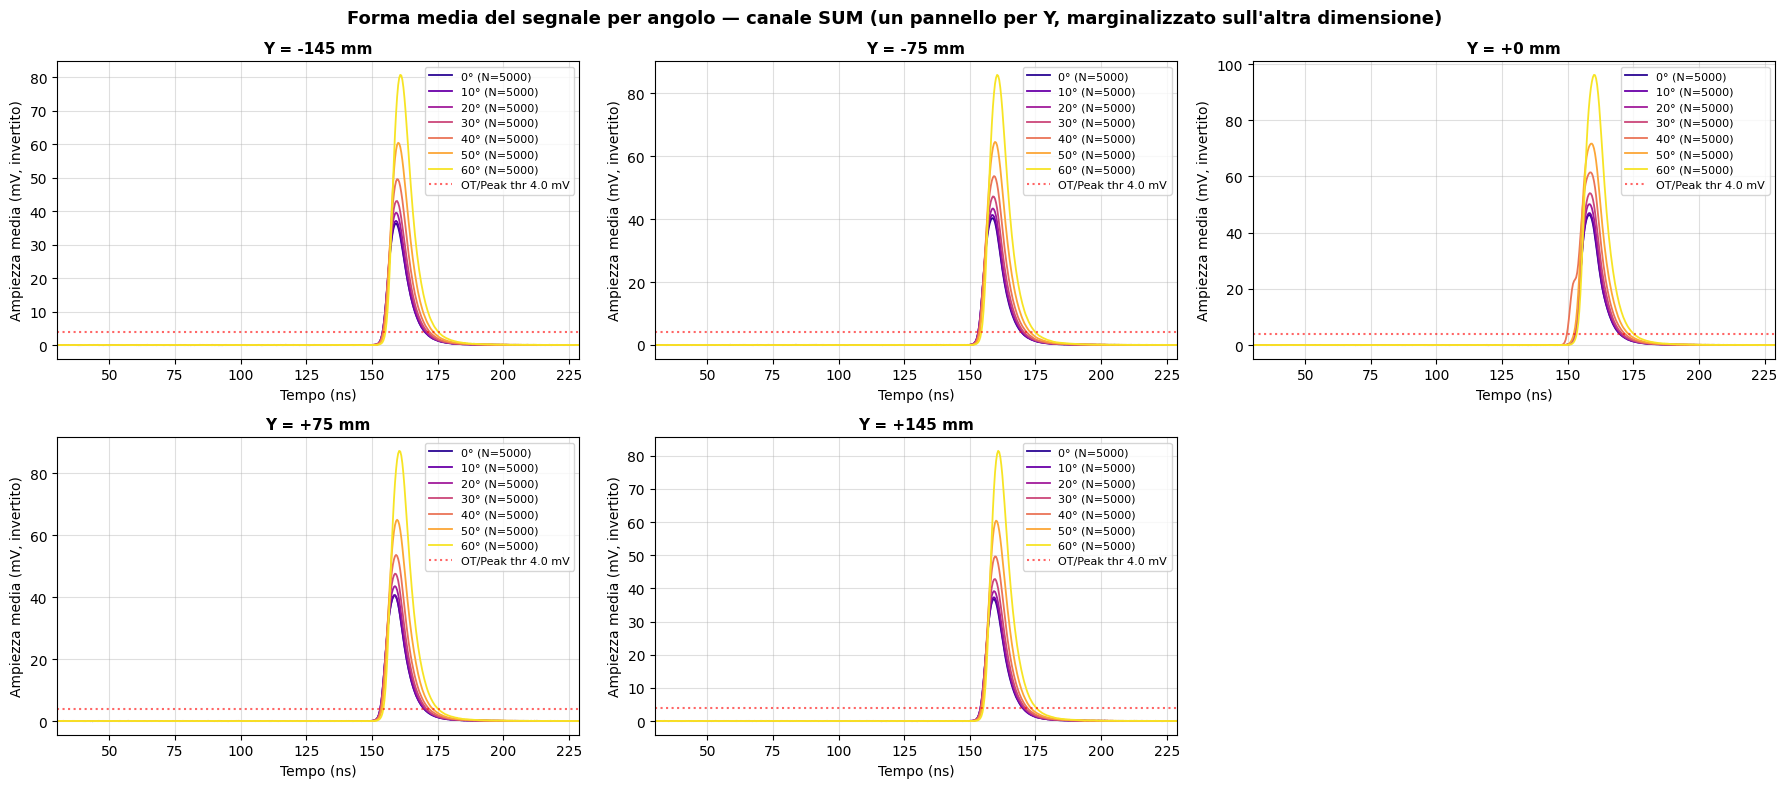

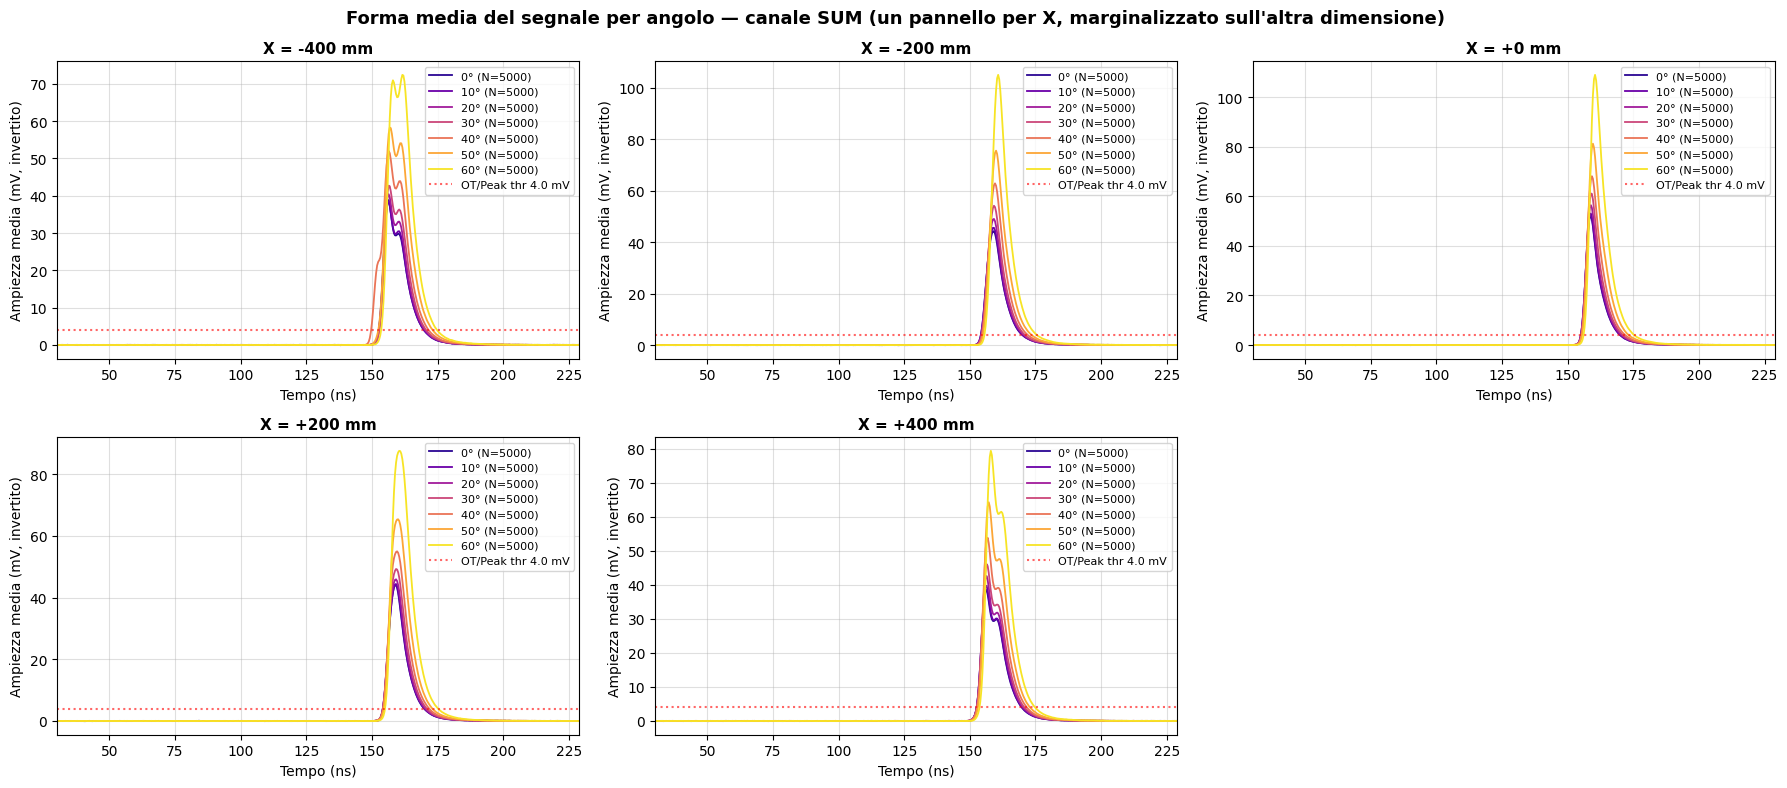

In [1]:
"""
============================================================
OT vs ANGOLO TRACCIA  (single-module Cherenkov + WLS)
============================================================
Script che legge i file .npz prodotti dal Signal_maker (formato
sim_Z<Z>_Y<Y>_X<X>_<DEG>Deg.npz) e calcola la durata Over-Threshold
del segnale al PMT (somma R+L) come funzione dell'angolo della traccia.

Output:
  1) Plot principale: OT medio ± std vs angolo
  2) Scatter di tutti gli eventi (OT vs angolo)
  3) Forma media del segnale per ciascun angolo (overlay)
  4) Stampa tabella riassuntiva su stdout
"""

import os
import re
import glob
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# PARAMETRI
# ============================================================
# Cartella contenente i .npz
MC_DIR = "/Users/benussi/Testbeam2026_WC_single/data"

# Range di angoli da analizzare (in gradi)
DEG_MIN = 0.0
DEG_MAX = 60.0

# Filtri opzionali (in mm). Lascia None per non filtrare.
X_RANGE = None        # es. (-50, 50) per analizzare solo eventi centrali in X
Y_RANGE = None        # es. (-30, 30) per analizzare solo eventi centrali in Y

# Digitizer (deve matchare il Signal_maker)
SAMPLE_RATE_GS = 2.5
DT_NS         = 1.0 / SAMPLE_RATE_GS              # = 0.4 ns/sample
RECORD_LENGTH = 1024
BASELINE_ADC  = 3800
V_PP_MV       = 1000.0
ADC_BITS      = 12
LSB_MV        = V_PP_MV / (2**ADC_BITS)            # ~ 0.244 mV/ADC

# Definizioni di canali logici per l'analisi.
# 'R'   = solo PMT destro (ch_0)
# 'L'   = solo PMT sinistro (ch_1)
# 'SUM' = somma R+L
CHANNEL_DEFS = {
    'R':   [0],
    'L':   [1],
    'SUM': [0, 1],
}

# Soglia OT in mV (sul segnale invertito = ampiezza positiva).
OT_THRESHOLD_MV = 4.0

# Parametri per il conteggio dei picchi (numpy implementation di find_peaks).
# - PEAK_THRESHOLD_MV: ampiezza minima del massimo locale. Allineata alla
#   soglia OT (5 mV) per catturare anche i picchi secondari piccoli nella
#   coda del pulse. La prominence filtra il rumore.
# - PEAK_MIN_DISTANCE_NS: distanza minima tra due picchi consecutivi.
# - PEAK_MIN_PROMINENCE_MV: il picco deve "sporgere" almeno N mV dalla valle
#   adiacente. Filtro CRUCIALE: permette di rilevare due picchi anche quando
#   il segnale non torna sotto la soglia tra di loro. 3 mV ≈ 4 sigma di
#   rumore (RMS ~0.85 mV) → praticamente immune al rumore.
# - PEAK_SEARCH_FROM_RISING: se True, cerca i picchi solo da quando il pulse
#   inizia (primo rising edge OT) fino a fine ROI. Evita picchi spurii nel
#   rumore pre-pulse e copre tutta la coda. Consigliato True.
PEAK_THRESHOLD_MV       = 5.0
PEAK_MIN_DISTANCE_NS    = 0.5
PEAK_MIN_PROMINENCE_MV  = 2.0
PEAK_MIN_DIST_SAMPLES   = max(int(PEAK_MIN_DISTANCE_NS / DT_NS), 1)
PEAK_SEARCH_FROM_RISING = True

# Parametri per l'integrale del segnale (carica).
# Il gate è definito relativamente al rising edge OT della SUM:
#   [rising - INTEGRAL_GATE_PRE_NS, rising + INTEGRAL_GATE_POST_NS]
# Lo stesso gate temporale è usato per i tre canali (R, L, SUM) così
# l'integrale è fisicamente confrontabile.
INTEGRAL_GATE_PRE_NS  = 10.0     # ns prima del rising edge
INTEGRAL_GATE_POST_NS = 150.0   # ns dopo il rising edge

# Region of Interest temporale dove cercare il pulse (samples).
TRIGGER_NS = 150.0
ROI_START_NS = TRIGGER_NS - 100.0     # = 50 ns
ROI_END_NS   = TRIGGER_NS + 59.0      # = 209 ns
ROI_START_SAMPLE = int(ROI_START_NS / DT_NS)
ROI_END_SAMPLE   = int(ROI_END_NS / DT_NS)

# Numero minimo di eventi per angolo (sotto questa soglia il punto è scartato)
MIN_EVENTS_PER_ANGLE = 5

# Numero di plot di debug da mostrare. Imposta a 0 per disabilitare.
MAX_DEBUG_PLOTS = 3

# Regex per il filename
FNAME_REGEX = re.compile(
    r'sim_Z([+-]?\d+\.?\d*)_Y([+-]?\d+\.?\d*)_X([+-]?\d+\.?\d*)_([+-]?\d+\.?\d*)Deg\.npz',
    re.IGNORECASE
)

# ============================================================
# FUNZIONI
# ============================================================
def parse_fname(fname):
    """Estrae (Z, Y, X, deg) dal nome file, None se non matcha."""
    m = FNAME_REGEX.match(fname)
    if not m:
        return None
    return float(m.group(1)), float(m.group(2)), float(m.group(3)), float(m.group(4))


def summed_signal_mv(event_dict, channels):
    """Restituisce la waveform sommata dei canali specificati, in mV positivi (pulse invertito)."""
    summed = np.zeros(RECORD_LENGTH, dtype=float)
    for ch in channels:
        key = f'ch_{ch}'
        if key not in event_dict:
            continue
        wf = event_dict[key].astype(float)
        summed += -(wf - BASELINE_ADC) * LSB_MV
    return summed


def compute_ot(summed_mv, threshold_mv, roi_start, roi_end):
    """Calcola Over-Threshold (in ns) sul segnale invertito.
    Cerca il primo rising-edge sopra la soglia dentro la ROI, poi il primo
    falling-edge successivo. Ritorna (ot_ns, rising_sample, falling_sample)."""
    if roi_start < 0: roi_start = 0
    if roi_end > RECORD_LENGTH: roi_end = RECORD_LENGTH
    above = summed_mv[roi_start:roi_end] > threshold_mv
    if not above.any():
        return 0.0, -1, -1
    idx_above = np.where(above)[0]
    rising_local = idx_above[0]
    below_after = np.where(~above[rising_local:])[0]
    if len(below_after) == 0:
        falling_local = len(above) - 1
    else:
        falling_local = rising_local + below_after[0] - 1
    ot_ns = (falling_local - rising_local + 1) * DT_NS
    return ot_ns, roi_start + rising_local, roi_start + falling_local


def _local_maxima(sig):
    """Trova gli indici dei massimi locali (strict): sig[i-1] < sig[i] > sig[i+1]."""
    if len(sig) < 3:
        return np.array([], dtype=int)
    d = np.diff(sig)
    rising  = d[:-1] > 0
    falling = d[1:]  < 0
    is_max = rising & falling
    return np.where(is_max)[0] + 1


def _prominence(sig, peaks):
    """Prominence di ogni picco, equivalente a scipy.signal.peak_prominences.
    Per ogni picco, cerca a sinistra/destra finché incontra un sample >= picco
    (o il bordo dell'array). Il minimo trovato in ciascun lato è la "base".
    La prominence è altezza_picco - max(base_sinistra, base_destra).
    """
    n = len(sig)
    out = np.empty(len(peaks), dtype=float)
    for k, p in enumerate(peaks):
        h = sig[p]
        # Base sinistra
        left_min = h
        i = p - 1
        while i >= 0 and sig[i] <= h:
            if sig[i] < left_min:
                left_min = sig[i]
            i -= 1
        # Base destra
        right_min = h
        i = p + 1
        while i < n and sig[i] <= h:
            if sig[i] < right_min:
                right_min = sig[i]
            i += 1
        out[k] = h - max(left_min, right_min)
    return out


def _find_peaks(sig, height=None, distance=None, prominence=None):
    """Versione numpy-only di scipy.signal.find_peaks con i 3 filtri usati qui.
    Ritorna l'array degli indici dei picchi mantenuti, ordinati per posizione."""
    peaks = _local_maxima(sig)
    if len(peaks) == 0:
        return peaks

    # Filtro per altezza
    if height is not None:
        peaks = peaks[sig[peaks] >= height]
        if len(peaks) == 0:
            return peaks

    # Filtro per prominence
    if prominence is not None and len(peaks) > 0:
        proms = _prominence(sig, peaks)
        peaks = peaks[proms >= prominence]
        if len(peaks) == 0:
            return peaks

    # Filtro per distance minima (greedy: tieni il più alto, scarta i vicini)
    if distance is not None and distance > 1 and len(peaks) > 1:
        heights = sig[peaks]
        order = np.argsort(-heights)        # ordine dal più alto al più basso
        keep = np.ones(len(peaks), dtype=bool)
        for idx in order:
            if not keep[idx]:
                continue
            for other in range(len(peaks)):
                if other != idx and keep[other]:
                    if abs(peaks[other] - peaks[idx]) < distance:
                        keep[other] = False
        peaks = peaks[keep]
        peaks = np.sort(peaks)

    return peaks


def compute_integral(summed_mv, rising_sample, gate_pre_ns, gate_post_ns):
    """Integrale del segnale nel gate [rising - gate_pre_ns, rising + gate_post_ns].

    Lavora sul segnale invertito (positivo) e ritorna l'integrale in
    "ADC counts" (somma dei sample dopo sottrazione della baseline, in
    unità ADC). La conversione è:
        Q_ADC = sum(summed_mv / LSB_MV)  over gate

    Se rising_sample < 0 (no pulse trovato), ritorna (0.0, -1, -1).
    Ritorna (integral_adc, gate_start_sample, gate_end_sample).
    """
    if rising_sample < 0:
        return 0.0, -1, -1
    pre_samples  = int(round(gate_pre_ns  / DT_NS))
    post_samples = int(round(gate_post_ns / DT_NS))
    gate_start = max(0, rising_sample - pre_samples)
    gate_end   = min(RECORD_LENGTH, rising_sample + post_samples + 1)
    if gate_start >= gate_end:
        return 0.0, gate_start, gate_end
    integral_adc = np.sum(summed_mv[gate_start:gate_end]) / LSB_MV
    return integral_adc, gate_start, gate_end


def count_peaks(summed_mv, threshold_mv, roi_start, roi_end,
                min_dist_samples, min_prominence_mv, start_from=None):
    """Conta i picchi locali del segnale invertito dentro la ROI.

    Equivalente numpy-only di scipy.signal.find_peaks. Tre filtri:
      - height = threshold_mv: ampiezza minima del massimo locale
      - distance = min_dist_samples: distanza minima fra picchi successivi
      - prominence = min_prominence_mv: il massimo locale deve sporgere
        almeno N mV dalla valle adiacente. Filtro CRUCIALE: permette
        di rilevare due picchi anche quando il segnale non torna sotto
        la soglia tra di loro (caso comune per pulse multi-modali).

    Se start_from è dato (indice globale del primo rising edge OT), la
    ricerca parte da quel sample invece che da roi_start. Utile per
    evitare di contare picchi spurii nel rumore pre-pulse.

    Ritorna (n_peaks, array_indici_picchi_globali).
    """
    if roi_start < 0: roi_start = 0
    if roi_end > RECORD_LENGTH: roi_end = RECORD_LENGTH
    if start_from is not None and start_from > roi_start:
        roi_start = start_from
    if roi_start >= roi_end:
        return 0, np.array([], dtype=int)
    sig = summed_mv[roi_start:roi_end]
    peaks_local = _find_peaks(
        sig,
        height=threshold_mv,
        distance=min_dist_samples,
        prominence=min_prominence_mv,
    )
    return len(peaks_local), peaks_local + roi_start


# ============================================================
# LOOP SUI FILE
# ============================================================
print(f"Cerco file .npz in: {MC_DIR}")
files = sorted(glob.glob(os.path.join(MC_DIR, "*.npz")))
print(f"Trovati {len(files)} file totali.")
print(f"Peak finder: numpy-only (height={PEAK_THRESHOLD_MV} mV, "
      f"distance={PEAK_MIN_DIST_SAMPLES} samples = {PEAK_MIN_DISTANCE_NS} ns, "
      f"prominence={PEAK_MIN_PROMINENCE_MV} mV, "
      f"search_from_rising_edge={PEAK_SEARCH_FROM_RISING})")
print(f"Integrale Q: gate [-{INTEGRAL_GATE_PRE_NS:.1f}, +{INTEGRAL_GATE_POST_NS:.1f}] ns "
      f"dal rising edge della SUM, unità = ADC counts integrati")

# Strutture dati
ot_by_key       = {ch: {} for ch in CHANNEL_DEFS}
peaks_by_key    = {ch: {} for ch in CHANNEL_DEFS}
integral_by_key = {ch: {} for ch in CHANNEL_DEFS}
logQratio_by_key = {}   # (deg, X, Y) -> list[float] — log(Q_R/Q_L) per evento
wf_sum_by_key   = {ch: {} for ch in CHANNEL_DEFS}
n_by_key        = {ch: {} for ch in CHANNEL_DEFS}

files_processed = 0
events_total    = 0
debug_plots_saved = 0

for fpath in files:
    fname = os.path.basename(fpath)
    parsed = parse_fname(fname)
    if parsed is None:
        continue
    Z_pos, Y_pos, X_pos, deg = parsed

    if not (DEG_MIN <= deg <= DEG_MAX):
        continue
    if X_RANGE is not None and not (X_RANGE[0] <= X_pos <= X_RANGE[1]):
        continue
    if Y_RANGE is not None and not (Y_RANGE[0] <= Y_pos <= Y_RANGE[1]):
        continue

    try:
        data = np.load(fpath, allow_pickle=True)
    except Exception as e:
        print(f"  [!] Errore lettura {fname}: {e}")
        continue

    files_processed += 1
    for key_evt in data.files:
        ev = data[key_evt].item()
        events_total += 1

        ot_per_ch    = {}
        peaks_per_ch = {}
        peaks_idx_per_ch = {}
        integral_per_ch  = {}
        wf_per_ch    = {}
        edges_per_ch = {}
        for ch_name, ch_list in CHANNEL_DEFS.items():
            wf_ch = summed_signal_mv(ev, ch_list)
            ot_ch, rising_ch, falling_ch = compute_ot(
                wf_ch, OT_THRESHOLD_MV, ROI_START_SAMPLE, ROI_END_SAMPLE)
            # Per la ricerca dei picchi, parti dal rising edge del canale stesso
            # (se PEAK_SEARCH_FROM_RISING è True). Se il canale non ha pulse OT
            # valido (rising < 0), uso la ROI piena come fallback.
            if PEAK_SEARCH_FROM_RISING and rising_ch >= 0:
                pk_start = rising_ch
            else:
                pk_start = None
            n_peaks_ch, peaks_idx_ch = count_peaks(
                wf_ch, PEAK_THRESHOLD_MV, ROI_START_SAMPLE, ROI_END_SAMPLE,
                PEAK_MIN_DIST_SAMPLES, PEAK_MIN_PROMINENCE_MV,
                start_from=pk_start)
            ot_per_ch[ch_name]       = ot_ch
            peaks_per_ch[ch_name]    = n_peaks_ch
            peaks_idx_per_ch[ch_name] = peaks_idx_ch
            wf_per_ch[ch_name]       = wf_ch
            edges_per_ch[ch_name]    = (rising_ch, falling_ch)

        # Integrale del segnale: gate identico per R, L, SUM, definito dal
        # rising edge della SUM. Così l'integrale è confrontabile tra canali.
        rising_sum = edges_per_ch['SUM'][0]
        gate_start = -1
        gate_end   = -1
        for ch_name in CHANNEL_DEFS:
            q_adc, g_s, g_e = compute_integral(
                wf_per_ch[ch_name], rising_sum,
                INTEGRAL_GATE_PRE_NS, INTEGRAL_GATE_POST_NS)
            integral_per_ch[ch_name] = q_adc
            # I gate_start/end sono uguali per tutti i canali; li tengo per il debug plot
            gate_start = g_s
            gate_end   = g_e

        if ot_per_ch['SUM'] <= 0:
            continue

        agg_key = (deg, X_pos, Y_pos)
        for ch_name in CHANNEL_DEFS:
            ot_ch  = ot_per_ch[ch_name]
            np_ch  = peaks_per_ch[ch_name]
            q_ch   = integral_per_ch[ch_name]
            wf_ch  = wf_per_ch[ch_name]
            if ot_ch > 0:
                ot_by_key[ch_name].setdefault(agg_key, []).append(ot_ch)
            peaks_by_key[ch_name].setdefault(agg_key, []).append(np_ch)
            integral_by_key[ch_name].setdefault(agg_key, []).append(q_ch)
            if agg_key not in wf_sum_by_key[ch_name]:
                wf_sum_by_key[ch_name][agg_key] = np.zeros(RECORD_LENGTH, dtype=float)
                n_by_key[ch_name][agg_key] = 0
            wf_sum_by_key[ch_name][agg_key] += wf_ch
            n_by_key[ch_name][agg_key] += 1

        # log(Q_R/Q_L) — asimmetria di carica (sensibile a X, possibile dipendenza da θ)
        Q_R_val = integral_per_ch['R']
        Q_L_val = integral_per_ch['L']
        if Q_R_val > 0 and Q_L_val > 0:
            logQratio_by_key.setdefault(agg_key, []).append(
                float(np.log(Q_R_val / Q_L_val)))

        wf      = wf_per_ch['SUM']
        ot      = ot_per_ch['SUM']
        rising, falling = edges_per_ch['SUM']

        # ------------------------------------------------------------
        # DEBUG PLOT
        # ------------------------------------------------------------
        if debug_plots_saved < MAX_DEBUG_PLOTS:
            time_axis_dbg = np.arange(RECORD_LENGTH) * DT_NS
            n_panels = 3
            fig_dbg, axes_dbg = plt.subplots(n_panels, 1,
                                              figsize=(12, 2.5 * n_panels),
                                              sharex=True)

            single_ch_names = ['R', 'L']
            for i, ch_name in enumerate(single_ch_names):
                ax = axes_dbg[i]
                ch_idx = CHANNEL_DEFS[ch_name][0]
                key_ch = f'ch_{ch_idx}'
                if key_ch in ev:
                    wf_ch_orig = (ev[key_ch].astype(float) - BASELINE_ADC) * LSB_MV
                    ax.plot(time_axis_dbg, wf_ch_orig, color='darkcyan', linewidth=1.2)
                    pulse_amp = np.min(wf_ch_orig)
                    ot_ind = ot_per_ch[ch_name]
                    n_pk = peaks_per_ch[ch_name]
                    q_ind = integral_per_ch[ch_name]
                    ax.set_title(
                        f'PMT {ch_name} (ch_{ch_idx}) | peak = {pulse_amp:.1f} mV '
                        f'| OT = {ot_ind:.2f} ns | N_peaks = {n_pk} | Q = {q_ind:.0f} ADC',
                        fontsize=10)
                    ax.axhline(-OT_THRESHOLD_MV, color='red', linestyle='--', alpha=0.5,
                               label=f'OT/Peak thr (-{OT_THRESHOLD_MV} mV)')
                    rising_ind, falling_ind = edges_per_ch[ch_name]
                    if rising_ind >= 0:
                        ax.axvline(rising_ind * DT_NS, color='green', linestyle='--', alpha=0.5)
                        ax.axvline(falling_ind * DT_NS, color='magenta', linestyle='--', alpha=0.5)
                    # Highlight del gate di integrazione (stesso per tutti i canali)
                    if gate_start >= 0 and gate_end > gate_start:
                        ax.axvspan(gate_start * DT_NS, gate_end * DT_NS,
                                   alpha=0.10, color='purple', zorder=0,
                                   label=f'Q gate [{gate_start*DT_NS:.0f}, {gate_end*DT_NS:.0f}] ns')
                    pk_idx = peaks_idx_per_ch[ch_name]
                    if len(pk_idx) > 0:
                        pk_times = pk_idx * DT_NS
                        pk_amps  = wf_ch_orig[pk_idx]
                        ax.scatter(pk_times, pk_amps, color='red', s=80, zorder=5,
                                   marker='v', edgecolors='black', linewidth=0.5,
                                   label=f'{n_pk} peaks')
                    ax.legend(loc='lower right', fontsize=7)
                ax.axhline(0, color='gray', linestyle=':', alpha=0.5)
                ax.set_ylabel('mV', fontsize=10)
                ax.grid(True, alpha=0.4)

            ax = axes_dbg[-1]
            wf_orig = -wf
            ax.plot(time_axis_dbg, wf_orig, color='black', linewidth=1.5,
                    label='Sum R+L')
            ax.axhline(-OT_THRESHOLD_MV, color='red', linestyle='--', alpha=0.7,
                       label=f'OT/Peak thr (-{OT_THRESHOLD_MV} mV)')
            ax.axvspan(ROI_START_NS, ROI_END_NS, alpha=0.08, color='gold',
                       label=f'ROI [{ROI_START_NS:.0f}, {ROI_END_NS:.0f}] ns')
            if rising >= 0:
                t_rise = rising * DT_NS
                t_fall = falling * DT_NS
                ax.axvline(t_rise, color='green', linestyle='--', alpha=0.8,
                           label=f'Rising edge @ {t_rise:.1f} ns')
                ax.axvline(t_fall, color='magenta', linestyle='--', alpha=0.8,
                           label=f'Falling edge @ {t_fall:.1f} ns')
                ax.axvspan(t_rise, t_fall, alpha=0.15, color='lightgreen')
            pk_idx_sum = peaks_idx_per_ch['SUM']
            n_pk_sum   = peaks_per_ch['SUM']
            q_sum      = integral_per_ch['SUM']
            if len(pk_idx_sum) > 0:
                pk_amps_sum = wf_orig[pk_idx_sum]
                ax.scatter(pk_idx_sum * DT_NS, pk_amps_sum, color='red', s=80,
                           zorder=5, marker='v', edgecolors='black', linewidth=0.5,
                           label=f'{n_pk_sum} peaks')
            # Highlight del gate di integrazione
            if gate_start >= 0 and gate_end > gate_start:
                ax.axvspan(gate_start * DT_NS, gate_end * DT_NS,
                           alpha=0.10, color='purple', zorder=0,
                           label=f'Q gate [{gate_start*DT_NS:.0f}, {gate_end*DT_NS:.0f}] ns')
            ax.set_title(f'Sum R+L | OT = {ot:.2f} ns | N_peaks = {n_pk_sum} '
                         f'| Q = {q_sum:.0f} ADC',
                         fontsize=11, fontweight='bold')
            ax.set_xlabel('Time (ns)', fontsize=11)
            ax.set_ylabel('mV', fontsize=10)
            ax.grid(True, alpha=0.4)
            ax.legend(loc='lower right', fontsize=8)
            ax.set_xlim(0, RECORD_LENGTH * DT_NS)

            fig_dbg.suptitle(
                f'DEBUG Event #{debug_plots_saved+1}  |  '
                f'Angle={deg:.0f}°, X={X_pos:.0f} mm, Y={Y_pos:.0f} mm, Z={Z_pos:.0f} mm',
                fontsize=12, fontweight='bold')
            fig_dbg.tight_layout()
            plt.show()
            debug_plots_saved += 1

print(f"\nFile processati: {files_processed}")
print(f"Eventi totali  : {events_total}")
all_angles = sorted(set(k[0] for ch in CHANNEL_DEFS for k in ot_by_key[ch].keys()))
all_xs     = sorted(set(k[1] for ch in CHANNEL_DEFS for k in ot_by_key[ch].keys()))
all_ys     = sorted(set(k[2] for ch in CHANNEL_DEFS for k in ot_by_key[ch].keys()))
print(f"Angoli trovati : {all_angles}")
print(f"X trovate (mm) : {all_xs}")
print(f"Y trovate (mm) : {all_ys}")

# ============================================================
# FUNZIONI DI AGGREGAZIONE / TABELLE / PLOT
# ============================================================
# La chiave dei dizionari è (deg, X, Y). Le funzioni qui sotto raggruppano
# gli eventi per una "dimensione separatrice" (X o Y) marginalizzando l'altra.

def aggregate(data_by_key, min_events, sep_dim):
    """Aggrega dati separando per sep_dim ('X' o 'Y') e marginalizzando l'altra.

    Ritorna: dict ch -> sep_value -> {angles, mean, std, sem, n, slope, intercept, pearson}.
    """
    sep_idx = 1 if sep_dim == 'X' else 2
    all_sep_values = sorted(set(k[sep_idx] for ch in data_by_key
                                          for k in data_by_key[ch]))
    out = {ch: {} for ch in data_by_key}
    for ch in data_by_key:
        for sep_val in all_sep_values:
            angles_list, mean_list, std_list, sem_list, n_list = [], [], [], [], []
            for ang in all_angles:
                # Tutti gli eventi con (deg=ang, sep_dim=sep_val), gli altri marginalizzati
                vals = []
                for k, v in data_by_key[ch].items():
                    if k[0] == ang and k[sep_idx] == sep_val:
                        vals.extend(v)
                if len(vals) < min_events:
                    continue
                arr = np.array(vals, dtype=float)
                angles_list.append(ang)
                mean_list.append(arr.mean())
                std_list.append(arr.std())
                sem_list.append(arr.std() / np.sqrt(len(arr)))
                n_list.append(len(arr))
            if len(angles_list) == 0:
                continue
            r = {
                'angles': np.array(angles_list),
                'mean':   np.array(mean_list),
                'std':    np.array(std_list),
                'sem':    np.array(sem_list),
                'n':      np.array(n_list),
                'slope':  None, 'intercept': None, 'pearson': None,
            }
            if len(angles_list) >= 3:
                slope, intercept = np.polyfit(angles_list, mean_list, 1)
                r['slope']     = slope
                r['intercept'] = intercept
                r['pearson']   = np.corrcoef(angles_list, mean_list)[0, 1]
            out[ch][sep_val] = r
    return out


def print_table(results_dict, observable_name, unit_label, sep_label):
    """Stampa la tabella riassuntiva. sep_label è 'X' o 'Y' (etichetta colonna)."""
    for ch in CHANNEL_DEFS:
        print("\n" + "="*82)
        print(f"  CANALE: {ch}  (PMT_ID = {CHANNEL_DEFS[ch]})  —  "
              f"Osservabile: {observable_name}  —  Separato per {sep_label}")
        print("="*82)
        print(f"{sep_label+' (mm)':>10} {'Angle':>8} {'N_evt':>8} "
              f"{'<'+observable_name+'>':>14} {'sigma':>10} {'SEM':>10}")
        print("-"*82)
        for sv in sorted(results_dict[ch].keys()):
            r = results_dict[ch][sv]
            for i in range(len(r['angles'])):
                print(f"{sv:>10.1f} {r['angles'][i]:>8.1f} {r['n'][i]:>8d} "
                      f"{r['mean'][i]:>14.3f} {r['std'][i]:>10.3f} {r['sem'][i]:>10.3f}")
        print("-"*82)
        print(f"  Fit lineare per {sep_label} (<{observable_name}> = slope*angle + intercept):")
        for sv in sorted(results_dict[ch].keys()):
            r = results_dict[ch][sv]
            if r['slope'] is not None:
                print(f"    {sep_label} = {sv:>+7.1f} mm  ->  slope = {r['slope']:>+7.4f} "
                      f"{unit_label}/deg, intercept = {r['intercept']:>7.3f} {unit_label}, "
                      f"r = {r['pearson']:>+5.3f}")
            else:
                print(f"    {sep_label} = {sv:>+7.1f} mm  ->  pochi punti, fit non possibile")
    print("="*82)


def plot_observable_vs_angle(results_dict, observable_name, unit_label,
                              sep_color_map, sep_label, title_suffix=''):
    """3 subplot R/L/SUM, curve per ciascun valore della dimensione separatrice."""
    fig, axes = plt.subplots(1, 3, figsize=(20, 5.5), sharey=False)
    for ax_idx, ch in enumerate(['R', 'L', 'SUM']):
        ax = axes[ax_idx]
        for sv in sorted(results_dict[ch].keys()):
            r = results_dict[ch][sv]
            c = sep_color_map[sv]
            label_main = f'{sep_label} = {sv:+.0f} mm'
            if r['slope'] is not None:
                label_main += f' (slope {r["slope"]:+.3f})'
            ax.errorbar(r['angles'], r['mean'], yerr=r['sem'],
                        fmt='o-', color=c, markersize=6, capsize=3, linewidth=1.3,
                        label=label_main)
            if r['slope'] is not None:
                a_range = np.linspace(r['angles'].min(), r['angles'].max(), 50)
                ax.plot(a_range, r['slope']*a_range + r['intercept'],
                        '--', color=c, alpha=0.45, linewidth=1.0)
        ax.set_xlabel('Angolo traccia (deg)', fontsize=11)
        ax.set_ylabel(f'Mean {observable_name} ({unit_label})', fontsize=11)
        ax.set_title(f'Canale {ch}', fontsize=12, fontweight='bold')
        ax.grid(True, alpha=0.4)
        ax.legend(fontsize=8, loc='best')
    fig.suptitle(f'{observable_name} vs angolo — per canale (R, L, SUM), separato per {sep_label} '
                 f'{title_suffix}', fontsize=13, fontweight='bold')
    fig.tight_layout()
    plt.show()


def plot_scatter_observable(data_dict, observable_name, unit_label,
                             sep_color_map, sep_label, title_suffix=''):
    """Scatter per evento, 3 subplot R/L/SUM, colore = valore della dimensione separatrice."""
    sep_idx = 1 if sep_label == 'X' else 2
    all_sep_values = sorted(set(k[sep_idx] for ch in data_dict for k in data_dict[ch]))
    fig, axes = plt.subplots(1, 3, figsize=(20, 5.5), sharey=False)
    for ax_idx, ch in enumerate(['R', 'L', 'SUM']):
        ax = axes[ax_idx]
        for sv in all_sep_values:
            c = sep_color_map[sv]
            first_pt = True
            for ang in all_angles:
                vals = []
                for k, v in data_dict[ch].items():
                    if k[0] == ang and k[sep_idx] == sv:
                        vals.extend(v)
                if len(vals) < MIN_EVENTS_PER_ANGLE:
                    continue
                arr = np.array(vals, dtype=float)
                jitter = np.random.uniform(-0.3, 0.3, size=len(arr))
                ax.scatter(np.full_like(arr, ang) + jitter, arr,
                           alpha=0.3, s=10, color=c,
                           label=f'{sep_label} = {sv:+.0f} mm' if first_pt else None)
                first_pt = False
        ax.set_xlabel('Angolo traccia (deg)', fontsize=11)
        ax.set_ylabel(f'{observable_name} per evento ({unit_label})', fontsize=11)
        ax.set_title(f'Canale {ch}', fontsize=12, fontweight='bold')
        ax.grid(True, alpha=0.4)
        ax.legend(fontsize=8, loc='best')
    fig.suptitle(f'Distribuzione {observable_name} per evento — separato per {sep_label} '
                 f'{title_suffix}', fontsize=13, fontweight='bold')
    fig.tight_layout()
    plt.show()


# ============================================================
# AGGREGAZIONE & PLOT
# ============================================================
# Color maps coerenti: una per Y, una per X (palette diverse per distinguere)
viridis_cmap = plt.cm.viridis(np.linspace(0.05, 0.95, max(len(all_ys), 1)))
y_color_map = {y: viridis_cmap[i] for i, y in enumerate(all_ys)}

plasma_cmap = plt.cm.plasma(np.linspace(0.05, 0.95, max(len(all_xs), 1)))
x_color_map = {x: plasma_cmap[i] for i, x in enumerate(all_xs)}

# --- Aggregazione per Y (marginalizza X) ---
results_ot_by_y       = aggregate(ot_by_key,       MIN_EVENTS_PER_ANGLE, 'Y')
results_peaks_by_y    = aggregate(peaks_by_key,    MIN_EVENTS_PER_ANGLE, 'Y')
results_integral_by_y = aggregate(integral_by_key, MIN_EVENTS_PER_ANGLE, 'Y')

# --- Aggregazione per X (marginalizza Y) ---
results_ot_by_x       = aggregate(ot_by_key,       MIN_EVENTS_PER_ANGLE, 'X')
results_peaks_by_x    = aggregate(peaks_by_key,    MIN_EVENTS_PER_ANGLE, 'X')
results_integral_by_x = aggregate(integral_by_key, MIN_EVENTS_PER_ANGLE, 'X')

# --- Tabelle ---
print("\n#" + "#"*81)
print("#  AGGREGAZIONE PER Y (marginalizzata su X)")
print("#" + "#"*81)
print_table(results_ot_by_y,       'OT',      'ns',  'Y')
print_table(results_peaks_by_y,    'N_peaks', '',    'Y')
print_table(results_integral_by_y, 'Q',       'ADC', 'Y')

print("\n#" + "#"*81)
print("#  AGGREGAZIONE PER X (marginalizzata su Y)")
print("#" + "#"*81)
print_table(results_ot_by_x,       'OT',      'ns',  'X')
print_table(results_peaks_by_x,    'N_peaks', '',    'X')
print_table(results_integral_by_x, 'Q',       'ADC', 'X')

# --- Plot per Y (separati per Y, mediati su X) ---
plot_observable_vs_angle(results_ot_by_y, 'OT', 'ns', y_color_map, 'Y')
plot_scatter_observable(ot_by_key, 'OT', 'ns', y_color_map, 'Y')

plot_observable_vs_angle(results_peaks_by_y, 'N_peaks', '', y_color_map, 'Y')
plot_scatter_observable(peaks_by_key, 'N_peaks', '', y_color_map, 'Y')

plot_observable_vs_angle(results_integral_by_y, 'Q', 'ADC', y_color_map, 'Y',
    title_suffix=f'(gate [-{INTEGRAL_GATE_PRE_NS:.0f}, +{INTEGRAL_GATE_POST_NS:.0f}] ns)')
plot_scatter_observable(integral_by_key, 'Q', 'ADC', y_color_map, 'Y',
    title_suffix=f'(gate [-{INTEGRAL_GATE_PRE_NS:.0f}, +{INTEGRAL_GATE_POST_NS:.0f}] ns)')

# --- Plot per X (separati per X, mediati su Y) ---
plot_observable_vs_angle(results_ot_by_x, 'OT', 'ns', x_color_map, 'X')
plot_scatter_observable(ot_by_key, 'OT', 'ns', x_color_map, 'X')

plot_observable_vs_angle(results_peaks_by_x, 'N_peaks', '', x_color_map, 'X')
plot_scatter_observable(peaks_by_key, 'N_peaks', '', x_color_map, 'X')

plot_observable_vs_angle(results_integral_by_x, 'Q', 'ADC', x_color_map, 'X',
    title_suffix=f'(gate [-{INTEGRAL_GATE_PRE_NS:.0f}, +{INTEGRAL_GATE_POST_NS:.0f}] ns)')
plot_scatter_observable(integral_by_key, 'Q', 'ADC', x_color_map, 'X',
    title_suffix=f'(gate [-{INTEGRAL_GATE_PRE_NS:.0f}, +{INTEGRAL_GATE_POST_NS:.0f}] ns)')

# ============================================================
# log(Q_R/Q_L) vs angolo — separato per X (marginalizzato su Y)
# ============================================================
# Questa variabile è direttamente sensibile alla posizione X (Beer-Lambert)
# e potrebbe mostrare una dipendenza anche da θ (accoppiamento Cherenkov
# diverso per angoli diversi).

def aggregate_logQratio_by_x(data, min_events):
    """Aggrega log(Q_R/Q_L) per X, marginalizzando Y."""
    # print("Aggrega log(Q_R/Q_L) per X, marginalizzando Y.")
    out = {}
    all_x_vals = sorted(set(k[1] for k in data.keys()))
    for x_val in all_x_vals:
        angles_list, mean_list, std_list, sem_list, n_list = [], [], [], [], []
        for ang in all_angles:
            vals = []
            for k, v in data.items():
                if k[0] == ang and k[1] == x_val:
                    vals.extend(v)
            if len(vals) < min_events:
                continue
            arr = np.array(vals, dtype=float)
            angles_list.append(ang)
            mean_list.append(arr.mean())
            std_list.append(arr.std())
            sem_list.append(arr.std() / np.sqrt(len(arr)))
            n_list.append(len(arr))
        if len(angles_list) == 0:
            continue
        r = {
            'angles': np.array(angles_list),
            'mean':   np.array(mean_list),
            'std':    np.array(std_list),
            'sem':    np.array(sem_list),
            'n':      np.array(n_list),
            'slope':  None, 'intercept': None, 'pearson': None,
        }
        if len(angles_list) >= 3:
            slope, intercept = np.polyfit(angles_list, mean_list, 1)
            r['slope']     = slope
            r['intercept'] = intercept
            r['pearson']   = np.corrcoef(angles_list, mean_list)[0, 1]
        out[x_val] = r
    return out

results_logQr = aggregate_logQratio_by_x(logQratio_by_key, MIN_EVENTS_PER_ANGLE)

# --- Tabella ---
print("\n" + "="*82)
print("  log(Q_R/Q_L) vs angolo — separato per X (marginalizzato su Y)")
print("="*82)
print(f"{'X (mm)':>10} {'Angle':>8} {'N_evt':>8} {'<logQr>':>14} {'sigma':>10} {'SEM':>10}")
print("-"*82)
for x_val in sorted(results_logQr.keys()):
    r = results_logQr[x_val]
    for i in range(len(r['angles'])):
        print(f"{x_val:>10.1f} {r['angles'][i]:>8.1f} {r['n'][i]:>8d} "
              f"{r['mean'][i]:>+14.4f} {r['std'][i]:>10.4f} {r['sem'][i]:>10.4f}")
print("-"*82)
for x_val in sorted(results_logQr.keys()):
    r = results_logQr[x_val]
    if r['slope'] is not None:
        print(f"  X = {x_val:>+7.1f} mm  ->  slope = {r['slope']:>+8.5f} /deg, "
              f"intercept = {r['intercept']:>+8.4f}, r = {r['pearson']:>+5.3f}")

# --- Plot: media vs angolo ---
fig, ax = plt.subplots(figsize=(10, 6))
for x_val in sorted(results_logQr.keys()):
    r = results_logQr[x_val]
    c = x_color_map[x_val]
    label = f'X = {x_val:+.0f} mm'
    if r['slope'] is not None:
        label += f' (slope {r["slope"]:+.5f})'
    ax.errorbar(r['angles'], r['mean'], yerr=r['sem'],
                fmt='o-', color=c, markersize=7, capsize=4, linewidth=1.5,
                label=label)
    if r['slope'] is not None:
        a_range = np.linspace(r['angles'].min(), r['angles'].max(), 50)
        ax.plot(a_range, r['slope']*a_range + r['intercept'],
                '--', color=c, alpha=0.4, linewidth=1.0)
ax.axhline(0, color='black', linestyle=':', alpha=0.5)
ax.set_xlabel('Angolo traccia (deg)', fontsize=12)
ax.set_ylabel('log(Q_R / Q_L)', fontsize=12)
ax.set_title('log(Q_R/Q_L) vs angolo — separato per X (marginalizzato su Y)',
             fontsize=13, fontweight='bold')
ax.grid(True, alpha=0.4)
ax.legend(fontsize=9, loc='best')
plt.tight_layout()
plt.show()

# --- Scatter per evento ---
fig, ax = plt.subplots(figsize=(10, 6))
for x_val in sorted(x_color_map.keys()):
    c = x_color_map[x_val]
    first_pt = True
    for ang in all_angles:
        vals = []
        for k, v in logQratio_by_key.items():
            if k[0] == ang and k[1] == x_val:
                vals.extend(v)
        if len(vals) < MIN_EVENTS_PER_ANGLE:
            continue
        arr = np.array(vals, dtype=float)
        jitter = np.random.uniform(-0.3, 0.3, size=len(arr))
        ax.scatter(np.full_like(arr, ang) + jitter, arr,
                   alpha=0.2, s=6, color=c,
                   label=f'X = {x_val:+.0f} mm' if first_pt else None)
        first_pt = False
ax.axhline(0, color='black', linestyle=':', alpha=0.5)
ax.set_xlabel('Angolo traccia (deg)', fontsize=12)
ax.set_ylabel('log(Q_R / Q_L)', fontsize=12)
ax.set_title('Distribuzione log(Q_R/Q_L) per evento — separato per X',
             fontsize=13, fontweight='bold')
ax.grid(True, alpha=0.4)
ax.legend(fontsize=9, loc='best')
plt.tight_layout()
plt.show()


# ============================================================
# FORMA MEDIA SEGNALE per (angolo, separatore), un subplot per ogni
# valore del separatore. Sulla SUM. Una figura per "by Y" e una per "by X".
# ============================================================
def plot_mean_waveform(wf_sum_dict, n_dict, ch_for_shape, sep_label,
                       results_dict_for_keys):
    """Plotta la forma media segnale per (angolo, sep_value).
    wf_sum_dict[ch][(ang,X,Y)] = ndarray cumulativo; n_dict idem per i conteggi.
    sep_label: 'Y' o 'X'. results_dict_for_keys serve a sapere quali sep_value plottare.
    """
    sep_idx = 1 if sep_label == 'X' else 2
    sep_vals_with_data = sorted(results_dict_for_keys[ch_for_shape].keys())
    if len(sep_vals_with_data) == 0:
        return
    n_plots = len(sep_vals_with_data)
    ncols = min(3, n_plots)
    nrows = int(np.ceil(n_plots / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(6*ncols, 4*nrows), squeeze=False)
    fig.suptitle(f'Forma media del segnale per angolo — canale {ch_for_shape} '
                 f'(un pannello per {sep_label}, marginalizzato sull\'altra dimensione)',
                 fontsize=13, fontweight='bold')

    time_axis_full = np.arange(RECORD_LENGTH) * DT_NS
    for idx, sv in enumerate(sep_vals_with_data):
        row, col = idx // ncols, idx % ncols
        ax = axes[row][col]
        # Trova tutti gli angoli per cui esiste almeno un X (o Y) con questo sv
        angles_here = sorted(set(k[0] for k in wf_sum_dict[ch_for_shape].keys()
                                       if k[sep_idx] == sv))
        cmap_angles = plt.cm.plasma(np.linspace(0.05, 0.95, max(len(angles_here), 1)))
        for j, ang in enumerate(angles_here):
            # Aggrega le wf cumulative su tutti i valori dell'altra dimensione
            wf_acc = np.zeros(RECORD_LENGTH, dtype=float)
            n_acc  = 0
            for k, wfsum in wf_sum_dict[ch_for_shape].items():
                if k[0] == ang and k[sep_idx] == sv:
                    wf_acc += wfsum
                    n_acc  += n_dict[ch_for_shape][k]
            if n_acc < MIN_EVENTS_PER_ANGLE:
                continue
            wf_mean = wf_acc / n_acc
            ax.plot(time_axis_full, wf_mean, color=cmap_angles[j], linewidth=1.3,
                    label=f'{ang:.0f}° (N={n_acc})')
        ax.axhline(OT_THRESHOLD_MV, color='red', linestyle=':', alpha=0.6,
                   label=f'OT/Peak thr {OT_THRESHOLD_MV} mV')
        ax.set_xlim(ROI_START_NS - 20, ROI_END_NS + 20)
        ax.set_xlabel('Tempo (ns)', fontsize=10)
        ax.set_ylabel('Ampiezza media (mV, invertito)', fontsize=10)
        ax.set_title(f'{sep_label} = {sv:+.0f} mm', fontsize=11, fontweight='bold')
        ax.grid(True, alpha=0.4)
        ax.legend(fontsize=8, loc='upper right')

    for idx in range(len(sep_vals_with_data), nrows*ncols):
        axes[idx // ncols][idx % ncols].axis('off')

    fig.tight_layout()
    plt.show()


# Forma media: una figura per Y e una per X, sulla SUM
plot_mean_waveform(wf_sum_by_key, n_by_key, 'SUM', 'Y', results_ot_by_y)
plot_mean_waveform(wf_sum_by_key, n_by_key, 'SUM', 'X', results_ot_by_x)